## __`CS : Compressed Sensing of Images`__
Ce notebook explore l’acquisition comprimée (compressed sensing) d’images, en évaluant plusieurs modèles de parcimonie des coefficients dans une base d’ondelettes, afin d’améliorer la qualité de reconstruction avec un nombre réduit de mesures.

La théorie du compressed sensing s’appuie sur l’idée que l'on peut reconstruire un signal à partir de beaucoup moins de mesures que sa dimension, à condition qu’il soit parcimonieux c-a-d que la plupart de ses coefficients soient nuls dans une base adaptée.
##### __`Cadre de base`__
On observe un **signal** $m \in \mathbb{R}^N$ `via des mesures linéaires` tel que :
$\Large y = A m \text{ <> } \Large y = A(\Psi^{-1}x)$
Les composantes de $\large \mathbb y$ représentent les mesures physiques issues d'un dispositif d’acquisition (combinaisons linéaires de pixels). Dans ce régime ou $len(y)=M$, $M≪N$, le système est sous‑déterminé car il existe une infinité de $\large \mathbb m$ compatibles avec $\large \mathbb y$. La matrice $\large \mathbb A$ décrit comment l’appareil de mesure combine les composantes de $m$ (optique, capteur, ...etc.).
- N dimension du signal (longueur du vecteur ou nombre de pixels)
- M nombre de mesures (nombre de lignes de A)
- $\large \mathbb m \in R^N$ le signal dans le domaine original (image, son, etc.)
- $A \in \mathbb{R}^{M \times N}$ est une matrice de mesure et $M \ll N$
- $\large \mathbb y \in R^M$ vecteur de mesures 
Les “coefficients” sparsifiés désignent les composantes de $x = \Psi m $ dans une base adaptée (ondelettes, etc.), sur lesquelles on impose la parcimonie.
$\Large x = \Psi m \text{ <=> } \Large m = \Psi^{-1} x$
- $x$ le signal sparse, c’est‑à‑dire ses coefficients dans la base $\Psi$ (ondelettes, Fourier, …),.
- $\Psi$ transforme le signal $m$ en représentation sparse $x$ (ondelettes, Fourier, etc,).
- $m\in R^N$ le signal dans le domaine original (image, son, etc.)
- $\Psi^{-1}$ opérateur inverse qui reconstruit $m$ à partir de $x$.

#### _`Rôle de la parcimonie`_
La parcimonie sert à sélectionner, parmi toutes les solutions compatibles avec les mesures, celle dont la représentation $x$ dans la base $\Psi$ est la plus “rare” (peu de coefficients non nuls).
- On souhaiterait résoudre : $ \min_{x} \|x\|_0 \text{ sous la contrainte } \large  y = A \Psi^{-1} x$
Mais ce problème en $\ell_0$ est combinatoire et NP‑difficile, 
- On le remplace donc par $ \min_{x} \|x\|_1$  sous la contrainte $ y = A \Psi^{-1} x$  convexe sous hypothèses appropriées sur A

La minimisation en norme $\ell_1$ permet de retrouver la solution parcimonieuse, même lorsque $M \ll N$.
- l’astuce de CS est d’ajouter l’hypothèse de parcimonie sur le signal, 
- on suppose qu’il admet une représentation $x = \Psi.m$, dans une base ou dictionnaire $\Psi$, 
- $x$ est K‑parcimonieux, si le vecteur $x$ ne possède qu'un petit nombre $K$ de coefficients non nuls, 
- tel qu'écrit $x = \Psi.\alpha$ avec $\alpha$ ayant peu de coefficients significatifs dans une base $\Psi$.

#### `Intuition pour les images naturelles`
Pour une image $m$, on prend souvent $x = \Psi \alpha$ avec $\Psi$ base d’ondelettes, car :
- les images naturelles ont des coefficients d’ondelettes qui décroissent vite avec l’échelle.  
- elles sont bien approchées par un **petit nombre** de coefficients significatifs (bords, contours),
- donc $\alpha$ est parcimonieux ou compressible. 
`De ce fait l'on peut:`
1. Mesurer directement $y = A.m$ avec $M \ll N$.  
2. Reconstruire $\hat m$ en résolvant un problème de minimisation $\ell_1$ sur les coefficients ondelettes. 
##### __`Synthèse`__
On cherche à reconstruire un signal $x∈R^N$ à partir d’un nombre de mesures linéaires $M≪N$, données par $y=Ax$. 
_`La clé est l’hypothèse de parcimonie suppose que:`_ 
- $x$ est sparse ou compressible dans une base adaptée, c-a-d qu’il peut s’écrire $x=\Phi\alpha$ 
- avec un vecteur de coefficients $\alpha$ comportant peu de composantes significatives. 
- sous des hypothèses appropriées sur la matrice de mesure $A$ (incohérence, propriété de type RIP),
- on peut retrouver $x$ en résolvant un problème de minimisation de norme $\ell_1$ sur les coefficients $\alpha$, 
- permettant une reconstruction fidèle malgré un sous‑échantillonnage important.

In [2]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

#### `Filtre "passe-bas" mesures linéaires`
`Utiliser les mesures d'un filtre "pass-bas" pour retirer les basses fréquences de l'image`.
 - les images naturelles ne sont pas seulement parcimonieuses dans le domaine des ondelettes. 
 - elles présentent également une décroissance rapide des coefficients au fil des échelles. 
 - la graine d'ondelette grossières (passe-bas) concentrent une grande partie de l’énergie de l’image.
 - il est donc pertinent de mesurer directement les coefficients "pass-bas"
`Opérationnellement : `
 - cela revient à appliquer une décomposition en ondelettes, 
 - à extraire les coefficients d’approximation de niveau grossier, 
 - on met à zéro les coefficients $C_A$ d'approximation issus du passe‑bas.
 - puis à annuler ces coefficients lors de la reconstruction pour obtenir une image sans basses fréquences. » 

Maintenant nous chargeons une image $m \in \mathcal{R}^{n^2}$ de $n \times n$ pixels.

(256, 256)


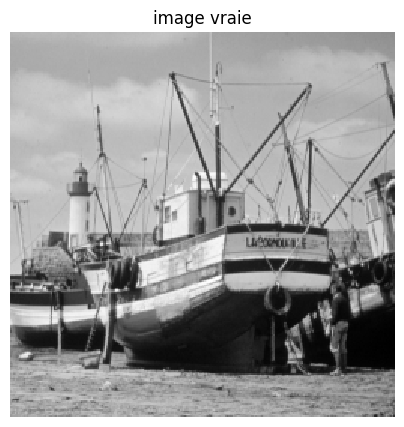

In [3]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/boat.bmp'
#n = 512
n = 256

f0 = load_image(name,n)          # f0.shape = (256, 256)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)

from skimage.transform import rescale

#f0= rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(5, 5))
imageplot(clamp(f0),'image vraie')

`Raccourci pour les transformés en ondelettes` $\{ \langle f, \Psi_m \rangle \}_m$
- Nous calculons la transformée jusqu'à l'échelle $J$ de sorte que seuls les sous-bandes $k_0$ sont transformées.
- Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base.

Définition de $P_f$ opérateur de projection passe‑bas sur l’espace d’approximation d’échelle J en fonction des coefficients d’approximation ondelettes $\Phi_{J,k}$ :
-  $P_f=\sum_k⟨f,\Phi_{J,k} ⟩\Phi_{J,k})$ et son lien avec la primitive wavedec2 

Mathématiquement, nous avons une décomposition du type où : 
- $\large f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$

  - $\Phi_{J,k}$ sont les fonctions d’échelle
  - $\Psi_{j,k}$ les ondelettes.
  - cA_J le premier bloc concatèné correspond aux coefficients d'approximation grossier basse fréquences.
  - cD_1, cD_2,.., cD_J sont les blocs suivants sont les coefficientsde détails de plus en plus grossiers suivant l'ordre.

Sert à fixer la plus petite échelle de la transformée en ondelettes, jusqu’à où descendre dans les décompositions en résolution.

`Que représente un coefficient`
Pour chaque échelle J et la position k :
- $\Phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\Psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle J et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

#### `Transformée en ondelettes discrètes 2D directe et inverse` 

In [4]:
import pywt
import numpy as np

# perform_direct_wavelet_transf transformée directe est un opérateur  
# qui prend une image et retourne la structure des coefficients d’ondelettes.
# Cette version est adaptée si tu fais juste du forward/inverse sans transformer 
# les coeffs en gros vecteur pour les mettre dans un solveur générique.
def direct_wavelet_transf(img,level,wavelet='db2'):
    coeffs_ti_2d = pywt.wavedec2(img, wavelet=wavelet, level=level, mode='periodization')
    return coeffs_ti_2d
# coeffs_ti_2d : version “hiérarchique” par niveau (ce que voit waverec2).
# coeffs_arr : version “aplatie” dans un seul array pour manipulations/visualisation.
# coeffs_slices : la carte qui relie les deux formats (pour couper/reconstituer correctement).

# perform_inverse_wavelet_transf l’opérateur inverse qui à partir des coefficients d’ondelettes, 
# reconstruit l’image, en appelant.
def inverse_wavelet_transf(coeffs_ti_2d,wavelet='db2'):
    f_rec = pywt.waverec2(coeffs_ti_2d, wavelet=wavelet, mode='periodization')
    return f_rec

# reconstruction depuis les coefficient d'ondelette
# Cette version est faite pour les situations où l'on veut travailler avec 
# un vecteur/array aplati de coefficients (pour du PG, ISTA, FISTA, etc.) 
# et revenir ensuite à la structure PyWavelets
def wv2d_inverse(coeffs_arr, coeffs_slices, wavelet='db2'):
    coeffs = pywt.array_to_coeffs(coeffs_arr, coeffs_slices, output_format='wavedec2')
    img = pywt.waverec2(coeffs, wavelet=wavelet)
    return img

`Calculer la transformée en ondelette.`

In [5]:
coeffs_ti_2d = direct_wavelet_transf(f0,level=3)
# Approximation au niveau le plus grossier
cA = coeffs_ti_2d[0]
print(f"cA_J : {cA.shape}, len(coeffs_ti_2d[1:] : {len(coeffs_ti_2d[1:])}), len(coeffs_ti_2d) : {len(coeffs_ti_2d)}\n")
# Détails : du niveau J jusqu'au niveau 1
for j, (cH, cV, cD) in enumerate(coeffs_ti_2d[1:], start=1):
    level = len(coeffs_ti_2d) - j   # juste pour numéroter J, J-1, ..., 1
    print(f"n: {n}, j: {j} Level {level}: cH_{level} {cH.shape}, cV_{level} {cV.shape}, cD_{level} {cD.shape}")

cA_J : (32, 32), len(coeffs_ti_2d[1:] : 3), len(coeffs_ti_2d) : 4

n: 256, j: 1 Level 3: cH_3 (32, 32), cV_3 (32, 32), cD_3 (32, 32)
n: 256, j: 2 Level 2: cH_2 (64, 64), cV_2 (64, 64), cD_2 (64, 64)
n: 256, j: 3 Level 1: cH_1 (128, 128), cV_1 (128, 128), cD_1 (128, 128)


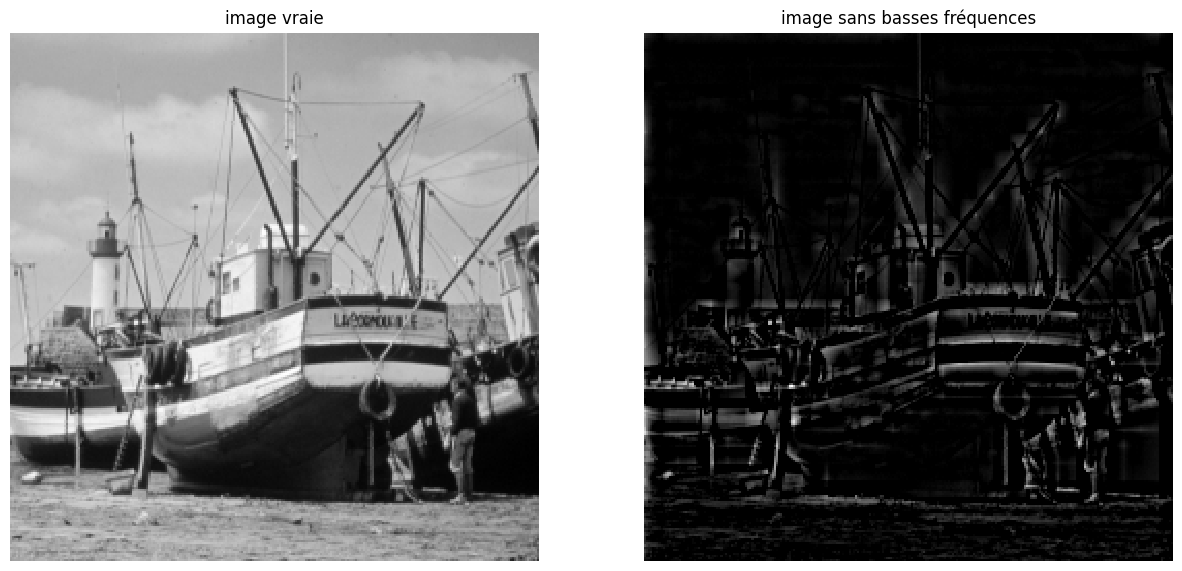

In [6]:
# Mise à zéro de cA (basses fréquences)
cA, details = coeffs_ti_2d[0], coeffs_ti_2d[1:]
cA_zero = np.zeros_like(cA)
coeffs_high = [cA_zero] + list(details)
f_vec = inverse_wavelet_transf(coeffs_high)
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_vec),'image sans basses fréquences',[1,2,2])

- LL = approximation → tons clairs uniformes (ciel, murs lisses)
- LH = contours verticaux  → hautes fréquences
- HL = contours horizontaux → hautes fréquences  
- HH = contours diagonaux   → hautes fréquences

On décompose l’image par ondelettes, ensuite nous annulons les coefficients d’approximation (passe‑bas), puis on reconstruit à partir des seuls coefficients de détail. Le résultat est une image où la composante basse fréquence a été retirée, ne laissant visibles que les structures de haute fréquence (contours, textures).

#### __`Exercice 1`__
Construire une approximation basse fréquence $∣f_{low}∣$ 
- Ne conserver que les coefficients passe‑bas, au nombre de $P=2^{2^J} =(n/k_0)^2$ : 
  - image est de taille $n×n$.
  - on travaille avec une décomposition ondelette 2D à $J=log2(n)−k0$ niveaux.
  - au niveau le plus grossier, le bloc basse fréquence (cA_J) est de taille $(n/2^{k_0})×(n/2^{k_0})$.
  - si on note $2^{k_0}=k_0$ => $(n/2^{k_0})×(n/2^{k_0}) \equiv (n/{k_0})^2$ => $P=2^{2^J} =(n/k_0)^2$
  - P correspond au nombre de coefficients passe‑bas utilisés pour construire $f_{low}$

cA.shape : (32, 32), 64*64 : 4096, f_low.shape : (256, 256)


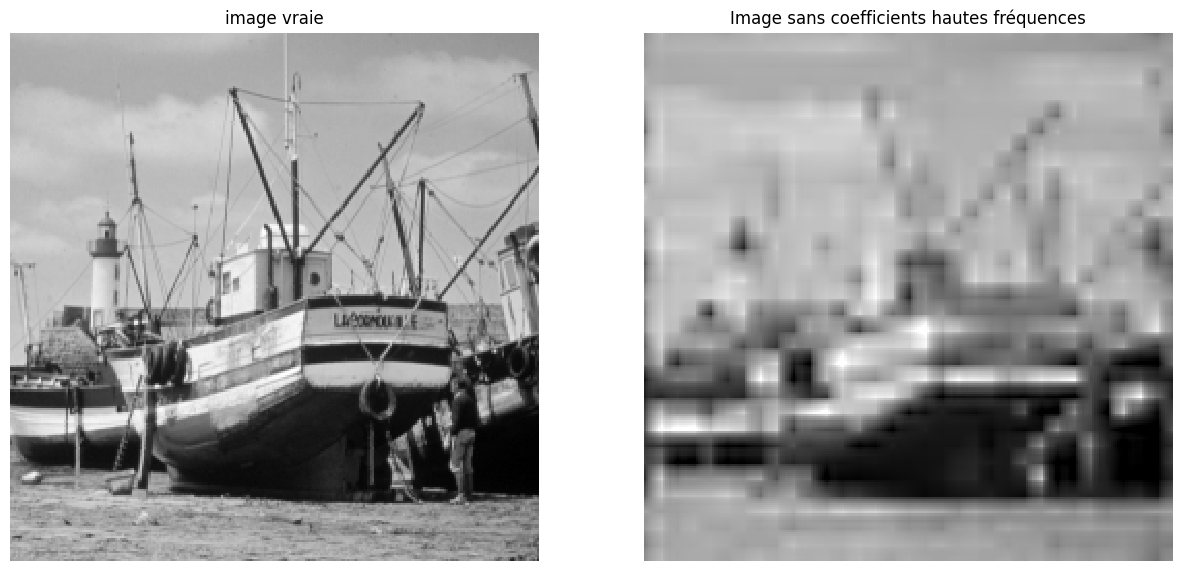

In [7]:
details_zero = [(np.zeros_like(cH), np.zeros_like(cV),np.zeros_like(cD)) for (cH, cV, cD) in details]
coeffs_low = [cA] + details_zero
f_low = inverse_wavelet_transf(coeffs_low)
print(f"cA.shape : {cA.shape}, 64*64 : {64*64}, f_low.shape : {f_low.shape}")
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_low),f'Image sans coefficients hautes fréquences',[1,2,2])


### `Mesures orthogonales aléatoires`.
- Considérons un opérateur "compressed sensing" qui correspond à une projection orthogonal randomisée.
- Extraire les coefficients d'ondelettes haute-fréquences $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$.
   - A est un masque $n×n$ rempli de 1.
   - on met à 0 le bloc supérieur gauche de taille $2^J×2^J$
   - A == 0 = zone low-pass, 
   - A == 1 = zone high-pass

<table border="1" style="border-collapse:collapse; text-align:center; font-family:monospace;">
  <tr>
    <td style="width:30px; height:30px;">0<br><small>LL</small></td>
    <td style="width:30px; height:30px;">1<br><small>LH</small></td>
    <td rowspan="2" style="width:60px; height:60px;">1<br><small>LH</small></td>
  </tr>
  <tr>
    <td style="width:30px; height:30px;">1<br><small>HL</small></td>
    <td style="width:30px; height:30px;">1<br><small>HH</small></td>
  </tr>
  <tr>
    <td colspan="2" style="width:60px; height:60px;">1<br><small>HL</small></td>
    <td style="width:60px; height:60px;">1<br><small>HH</small></td>
  </tr>
</table>
<div>
</div>

| Zone                                           | Valeur dans A | Rôle                             |
| ---------------------------------------------- | ------------- | -------------------------------- |
| Bloc $2^J \times 2^J$ en haut à gauche | 0             | Low-pass (exclus de $I_0$)    |
| Tout le reste                                  | 1             | High-pass (inclus dans $I_0​$) |

#### `Extrait du vecteur de coefficients d'ondelettes haute-fréquence` 
$$\large x_0={⟨f,ψ.m⟩}m∈I_0$$
- `pywt.coeffs_to_array` reconstruit l'image de coefficients (n x n) d'un coup et retourne : 
- `fw_img :`Recolle toutes les sous-bandes en une seule image 2D
- `slices :`Retourne les positions de chaque sous-bande dans fw_img

In [8]:
# Reconstruire l'image de coefficients (n x n) d'un coup
# fw_img — Recolle toutes les sous-bandes en une seule image 2D
# slices — Retourne les positions de chaque sous-bande dans fw_img
coeffs_arr, coeffs_slices = pywt.coeffs_to_array(coeffs_ti_2d)
A = np.ones((coeffs_arr.shape))  
A[0:coeffs_slices[0][0].stop,0:coeffs_slices[0][1].stop] = 0
# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]
x0 = coeffs_arr.flatten()[I0]

print(f"low_h : {coeffs_slices[0][0].stop}, low_w : {coeffs_slices[0][1].stop}  => {coeffs_slices[0][0].stop**2}")
print(f"A.shape : {A.shape} => {A.flatten().shape}")
print(f"I0.shape : {I0.shape} => len(I0)+low_h**2 : {len(I0)+coeffs_slices[0][0].stop**2}")
print(f"Nombre de niveaux : {len(coeffs_ti_2d) - 1}, fw_img.shape : {coeffs_arr.shape}, {coeffs_arr.shape[0]*coeffs_arr.shape[0]} , A.shape : {A.shape}, I0.shape : {I0.shape}")
print(f"n: {n}, Le nombre de coefficients haute fréquence est : {len(x0)}, (len(x0)+low_h**2) : {len(x0)+coeffs_slices[0][0].stop**2}")

low_h : 32, low_w : 32  => 1024
A.shape : (256, 256) => (65536,)
I0.shape : (64512,) => len(I0)+low_h**2 : 65536
Nombre de niveaux : 3, fw_img.shape : (256, 256), 65536 , A.shape : (256, 256), I0.shape : (64512,)
n: 256, Le nombre de coefficients haute fréquence est : 64512, (len(x0)+low_h**2) : 65536


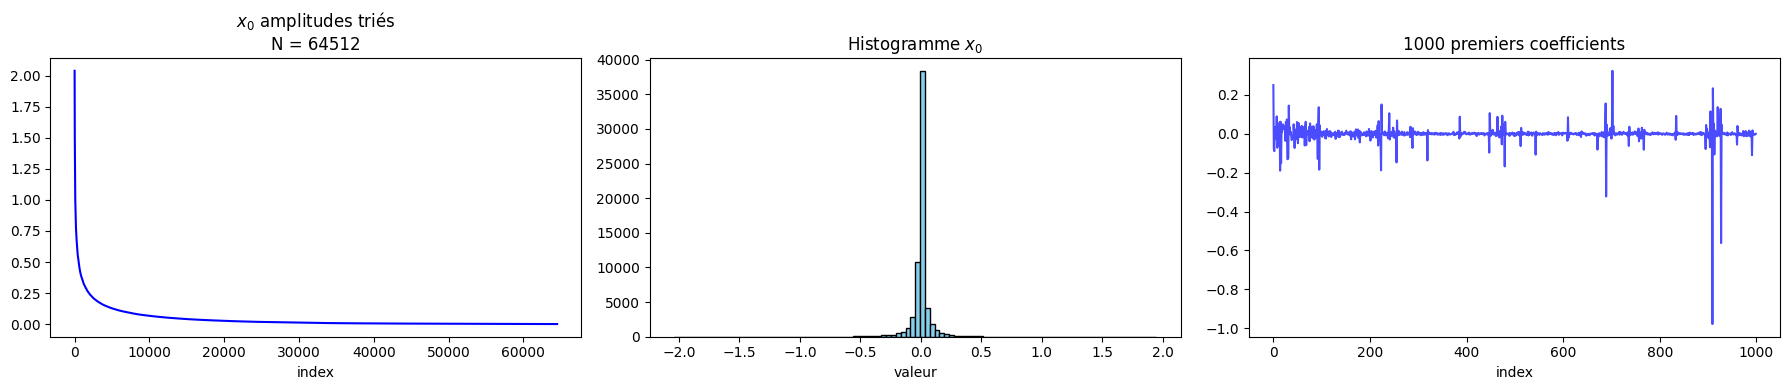

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Amplitudes triées
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ amplitudes triés\nN = {len(x0)}')
axes[0].set_xlabel('index')

# 2. Histogramme
axes[1].hist(x0, bins=100, color='skyblue', edgecolor='k')
axes[1].set_title(f'Histogramme $x_0$')
axes[1].set_xlabel('valeur')

# 3. Zoom sur les 1000 premiers
axes[2].plot(x0[:1000], 'b-', alpha=0.7)
axes[2].set_title(f'1000 premiers coefficients')
axes[2].set_xlabel('index')

plt.tight_layout()
plt.show()

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse !

- `Figure 2:` Pic très marqué autour de 0 → la grande majorité des coefficients sont quasi nuls, confirmant la parcimonie vue dans la figure 1.

- `Figure 3:` Les coefficients oscillent autour de 0 avec quelques pics occasionnels. C'est typique des coefficients d'ondelettes où la plupart sont proches de 0, seuls quelques-uns (les contours de l'image) ont une amplitude significative.

#### `Nombre de mesures CS (acquisition ou mesure comprimée)`
__Idée principale__
- En traitement du signal classique (théorème de Shannon-Nyquist), 
- il faut au moins autant de mesures que de coefficients pour reconstruire un signal.
_`Le Compressed Sensing dit`_ : 
- si le signal est parcimonieux (sparse), 
- c'est-à-dire que la plupart de ses coefficients sont nuls ou quasi-nuls, 
- alors on peut le reconstruire avec beaucoup moins de mesures : $P$ (nombre de mesures) $<< N$ (nombre de pixels)

#### `Nombre de mesures basses fréquences:` 
 - $P_0 = 2^{2J}=(n/2^{k_0})^2 $
   - k0 profondeur de détails

In [10]:
k0=3
P0 = (n/2**k0)**2
print(f"n: {n}, Le nombre de de mesures basse fréquence {P0}")

n: 256, Le nombre de de mesures basse fréquence 1024.0


##### __`Operateurs de permutations aléatoires`__ 
 - $S_1,S_2 : \mathcal{R}^N \rightarrow \mathcal{R}^N$ tel que $S_k(x)_i = x_{\sigma_k(i)}$ où $ \sigma_k \in \Sigma_N $ 
- soit une permutation aléatoire $\{1,\ldots,N\}$.

In [11]:
# x0 la liste d'indices des coefficients hautes fréquences
# N le nombre de coeeficients hautes fréquences pour une profondeur k0 de 3
N = len(x0)   # 64512
print(f"pour K0 = {k0}, le nombre de coefficients basse fréquences N = {len(x0)}")

# Deux permutations aléatoires sigma_1 et sigma_2
sigma1 = np.random.permutation(N)   # σ_1
sigma2 = np.random.permutation(N)   # σ_2

# Opérateurs directs
S  = lambda x,sigma: x[sigma]
# Opérateurs S_1 et S_2 appliqués à x0
S1_x0 = S(x0,sigma1)
S2_x0 = S(x0,sigma2)

pour K0 = 3, le nombre de coefficients basse fréquences N = 64512


##### __`Opérateurs adjoints ou inverses`__ 
 - $S_1^*,S_2^*$ (notés |$S_1^S, S_2^S|$) 
 - correspondant à la permutation inverse $\sigma_k^*$ tel que  $\sigma_k^* \circ \sigma_k(i)=i$.

In [12]:
# Permutations inverses (adjoints)
sigma1S = np.zeros(N, dtype=int)
sigma1S[sigma1] = np.arange(N)

sigma2S = np.zeros(N, dtype=int)
sigma2S[sigma2] = np.arange(N)

# Opérateurs inverses (adjoints)
Sinv_1 = lambda x,sigma1S: x[sigma1S]
Sinv_2 = lambda x,sigma2S: x[sigma2S]

##### __`Opérateur CS (acquisition ou mesure comprimée):`__ 
- $ \Phi:\mathcal{R}^N \rightarrow \mathcal{R}^P$ 
Une projection sur des atomes aléatoires correspond aux vecteurs colonnes de la matrice de mesure: 
- $ \Phi = [\Phi_1,\Phi_2,…,\Phi_N]$
 - $\Phi x = \begin{pmatrix} \langle x, \phi_1 \rangle & \langle x, \phi_2 \rangle & \cdots & \langle x, \phi_P \rangle \end{pmatrix}^\top$
 - $ (\Phi x)_i = \langle{x}{\Phi_{\sigma_2(i)}}\rangle $ 
   - ou $ \Phi_i $ est une base orthogonale mélangée (scrambled) : $ \Phi_i(x) = \large c_i( \sigma_1(x) ) $
   - où $\{ c_i \}_i$ est la base orthogonale DCT (Transformée en Cosinus Discrète).
`Cette opérateur peut s'écrire sous une forme compacte :` 
 - $ \Phi x = ( S_2 \circ C \circ S_1 (x) ) \downarrow_P $
   - où $S_1,S_2$ sont les opérateurs de permutation, 
   - et $\downarrow_P$ sélectionne les $P$ premières entrées du vecteur.
   - Attention se lit de gauche vers droite (application fonctionnelle) :
     - $S_1(x)   →   C(S_1(x))   →   S_2(C(S_1(x)))   →   [·]↓_P$
   - Attention à la notation compacte (algèbre linéaire) :
     - $Φ = ↓_P ∘ S_2 ∘ C ∘ S_1$ 

x (vecteur N coefficients high-pass)
Phi(x) = dP( S2( C( S1(x) ) ) )
- S1(x) : permutation aléatoire $\sigma 1$
    - ⬇️
- C(…) : transformée DCT orthogonale
   -  ⬇️
- S2(…) : permutation aléatoire $\sigma 2$
   -  ⬇️
- dP(…) : garder les P premières entrées  
   -  ⬇️
- y = $Φx$  (vecteur de P mesures)

In [13]:
from scipy.fft import dct, idct

P = N // 4   # nombre de mesures Shanon-Nyquist 
print(f"n: {n}, N: {N} P: {P}  P ≪ N")
# DCT orthogonale et son inverse
C     = lambda x: dct(x, norm='ortho')  # transformée en cosinus discrete dans une base orthogonale
Cinv  = lambda x: idct(x, norm='ortho') # transformée en cosinus discrete inverse dans une base orthogonale
dP    = lambda x,P: x[:P] # Sous-échantillonnage ↓_P : garder les P premières entrées
Phi   = lambda x,sigma1,sigma2,P: dP(S(C(S(x,sigma1)),sigma2),P) # Opérateur Φ : R^N → R^P

n: 256, N: 64512 P: 16128  P ≪ N


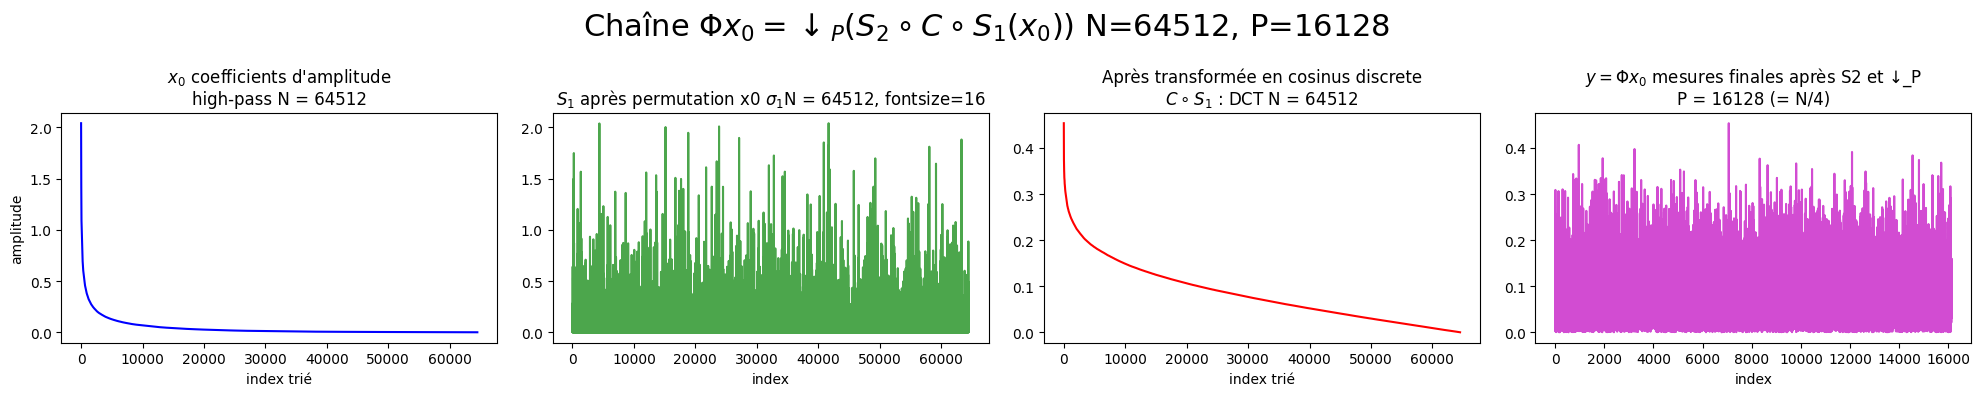

Nombre de coefficient haute fréquence : 64512
Nombre de mesures finales : 16128


In [14]:
# l'opérateur d'acquisition de mesures
y = Phi(x0,sigma1,sigma2,P)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. x0 : coefficients high-pass originaux
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ coefficients d\'amplitude\nhigh-pass N = {N}')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. Après S1 : permutation sigma1
S1_x0 = S(x0, sigma1)
axes[1].plot(np.abs(S1_x0), 'g-', alpha=0.7)
axes[1].set_title(f'$S_1$ après permutation x0 $\\sigma_1$N = {N}, fontsize=16')
axes[1].set_xlabel('index')

# 3. Après C∘S1 : DCT
CS1_x0 = C(S1_x0)
axes[2].plot(np.sort(np.abs(CS1_x0))[::-1], 'r-')
axes[2].set_title(f'Après transformée en cosinus discrete\n$C \\circ S_1$ : DCT N = {N}')
axes[2].set_xlabel('index trié')

# 4. y = Φx0 : mesures finales après S2 et ↓_P
axes[3].plot(np.abs(y), 'm-', alpha=0.7)
axes[3].set_title(f'$y = \\Phi x_0$ mesures finales après S2 et ↓_P\nP = {P} (= N/4)')
axes[3].set_xlabel('index')

plt.suptitle(f'Chaîne $\\Phi x_0 = \\downarrow_P(S_2 \\circ C \\circ S_1(x_0))$'f' N={N}, P={P}', fontsize=22)
plt.tight_layout()
plt.show()

print(f"Nombre de coefficient haute fréquence : {x0.shape[0]}")   # (N,)
print(f"Nombre de mesures finales : {y.shape[0]}")    # (P,)

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute-fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse!

- `Figure 2:` Les coefficients sont mélangés aléatoirement par la permutation $\sigma_1$. L'amplitude totale est conservée (même norme), mais l'ordre est perdu. C'est une étape de scrambling pour que l'information soit répartie uniformément avant la DCT.

- `Figure 3:` DCT concentre l'énergie, quelques coefficients ont une grande amplitude (à gauche) et le reste est quasi nul. La DCT est une base adaptée qui compresse encore mieux l'information que la base ondelette originale. C'est ce qui rend les mesures très efficaces.

- `Figure 4:` Les P = N/4 => 15360 mesures finales. Chaque valeur est le produit scalaire entre $x_0$ et un atome aléatoire. L'amplitude est distribuée uniformément entre toutes les mesures grâce au mélange $S_2 \circ C \circ S_1$. On a réduit N=61440 → P=15360 coefficients tout en préservant l'information essentielle.


_`Rappel :`_
- $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition de mesures comprimées sur les hautes fréquences
_`L'opérateur adjoint est :`_ 
 - $ \Phi^* x = S_1^* \circ C^* \circ S_2^* (x) \circ \uparrow_P $ 
 - `où` $\uparrow_P$ `ajoute  N - P zéros à la fin d'un vecteur` 
 - $C^*$ est la transformée cosinus discrète inverse.
 - Attention se lit de gauche vers droite (application fonctionnelle) : $S_2^*(x)   →   C^*(S_2^*(x))   →   S_1^*(C^*(S_1^*(x)))→ [·]\uparrow_P$
 - Attention à la notation compacte (algèbre linéaire) :$\Phi^*  = S_1^* ∘  C^*  ∘  S_2^* ∘  \uparrow_P$

In [15]:
# Φ* : R^P → R^N
uparrow = lambda x,N,P: np.concatenate([x, np.zeros(N - P)])
# L'opérateur adjoint 
PhiS  = lambda x,N,P,sigma1S,sigma2S: Sinv_1(Cinv(Sinv_2(uparrow(x,N,P), sigma2S)),sigma1S)

Effectuer les mesures de compressed sensing Perform CS (sans bruitage).

- $\large x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition ou de mesures comprimées

In [16]:
# l'opérateur d'acquisition de mesures
y = Phi(x0,sigma1,sigma2,P)
# L'opérateur adjoint 
z = PhiS(y,N,P,sigma1S,sigma2S)
print(f"n: {n}, phi.shape : {y.shape} phiS.shape : {z.shape}")

n: 256, phi.shape : (16128,) phiS.shape : (64512,)


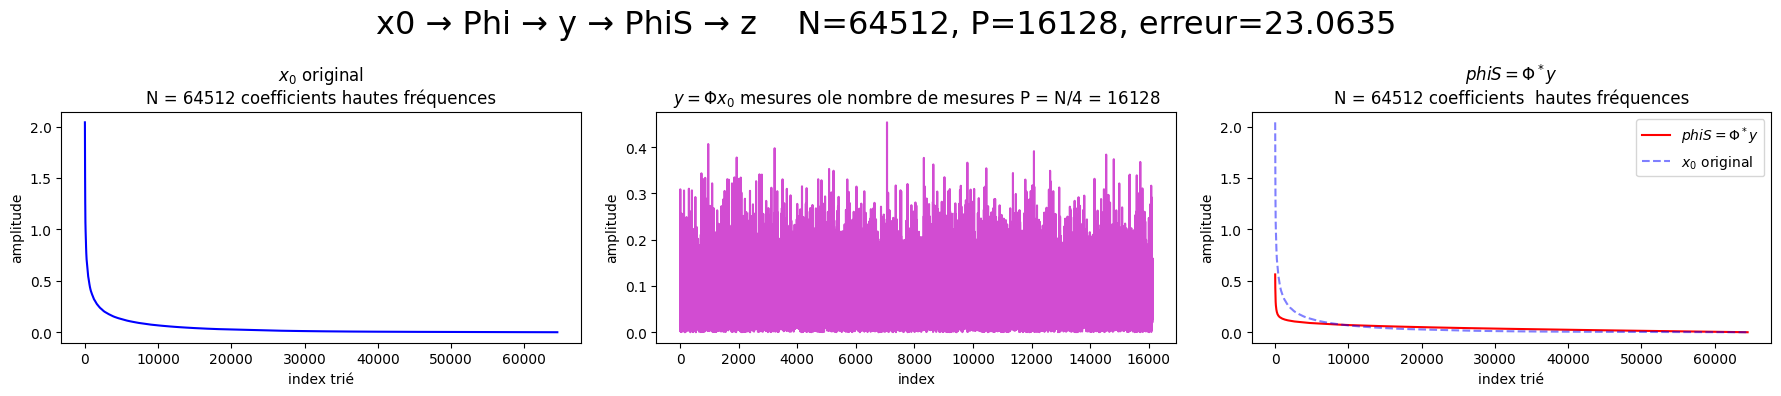

x0.shape          : (64512,)
y.shape           : (16128,)
z.shape           : (64512,)
||phiS - x0||     : 23.063505
||x0||            : 26.621626
erreur relative   : 0.866345


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. x0 original
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ original\nN = {N} coefficients hautes fréquences')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. y = Φx0 : mesures
axes[1].plot(np.abs(y), 'm-', alpha=0.7)
axes[1].set_title(f'$y = \\Phi x_0$ mesures ole nombre de mesures P = N/4 = {P}')
axes[1].set_xlabel('index')
axes[1].set_ylabel('amplitude')

# 3. z = Φ*y : reconstruction
axes[2].plot(np.sort(np.abs(z))[::-1], 'r-', label='$phiS = \\Phi^* y$')
axes[2].plot(np.sort(np.abs(x0))[::-1], 'b--', alpha=0.5, label='$x_0$ original')
axes[2].set_title(f'$phiS = \\Phi^* y$\nN = {N} coefficients  hautes fréquences')
axes[2].set_xlabel('index trié')
axes[2].set_ylabel('amplitude')
axes[2].legend()

# ← suptitle simplifié sans \xrightarrow
erreur = np.linalg.norm(z - x0)
plt.suptitle(f'x0 → Phi → y → PhiS → z    N={N}, P={P}, erreur={erreur:.4f}', fontsize=23)
plt.tight_layout()
plt.show()

# Vérification numérique
print(f"x0.shape          : {x0.shape}")
print(f"y.shape           : {y.shape}")
print(f"z.shape           : {z.shape}")
print(f"||phiS - x0||     : {np.linalg.norm(z - x0):.6f}")
print(f"||x0||            : {np.linalg.norm(x0):.6f}")
print(f"erreur relative   : {np.linalg.norm(z - x0) / np.linalg.norm(x0):.6f}")

- erreur relative ≈ 87% d'erreur, c'est le comportement attendu de $\Phi^∗$
- $\Phi^*$ agit comme un filtre passe-bas, il lisse et atténue $x0$
- La vraie reconstruction de $x0$ se fait via l'algorithme itératif (ISTA, FISTA...) $\min_x=\frac{1}{2}||\Phi x − y||^2+λG(x)$

#### __`Pseudo inverse de Moore-Penrose`__
__La propriété fondamentale de la pseudo-inverse Moore-Penrose est :__ 
- $\Phi^+=(\Phi^∗\Phi)^{−1}\Phi^∗$
__On considère un opérateur de compressed sensing :__ 
- $\Phi = \downarrow_P \circ \underbrace{\left(S_2 \circ C \circ S_1\right)}_{\text{orthogonal } U}=\downarrow_P \circ U$
__Pourquoi__ $\Phi^+ = \Phi^*$: 
 - $\Phi = \downarrow_P \circ S_2 \circ C \circ S_1$
 - $\Phi^∗=S_1^∗ \circ C^∗ \circ S_2^* \circ \uparrow_P$
 - $\Phi\Phi^∗= \downarrow_P \circ ( S_2 \circ C \circ S_1) \circ (S_1^∗ \circ C^∗ \circ S_2^∗ ) \circ \uparrow_P$
 - $\Phi\Phi^∗ = \downarrow_P \circ \underbrace{S_2 \circ C \circ S_1 \circ S_1^∗ \circ C^∗ \circ S_2^∗}_{=I}\circ\uparrow_P$ = $\downarrow_P \circ \uparrow_P=I_p$
__Calcul de__ $\Phi \Phi^*$ 
- on a : $\Phi \Phi^*= (\downarrow_P \circ U) \circ (U^* \circ \downarrow_P^*)= \downarrow_P \circ U U^* \circ \downarrow_P^*.$
 - comme $U$ est orthogonal ($U^* U = I$) : $\Phi \Phi^*= \downarrow_P \circ I \circ \downarrow_P^* = \downarrow_P \circ \downarrow_P^*$
__Donc__ : $ ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$ 

#### __`Exercice 2`__
- L'égalité $\Phi^+ y =\Phi^* y$ repose sur la notion de pseudo-inverse de Moore-Penrose permettant la  reconstruction d'une image. 
- Pour une matrice $\Phi \in \mathbb{R}^{P \times N}$, la pseudo-inverse $\Phi^+$ définie la solution du problème $min_x ||x||_2$ sous contrainte $\Phi_x=y$
- L'égalité $\Phi^+ = \Phi^*$ est valable car $\Phi$ est construit à partir d'opérations orthogonales (permutations + DCT orthogonale),

x_rec.shape : (64512,)
coeffs_arr : (256, 256), fw_rec_2d : (256, 256)
fw_rec : (65536,), coeffs_slices : 4


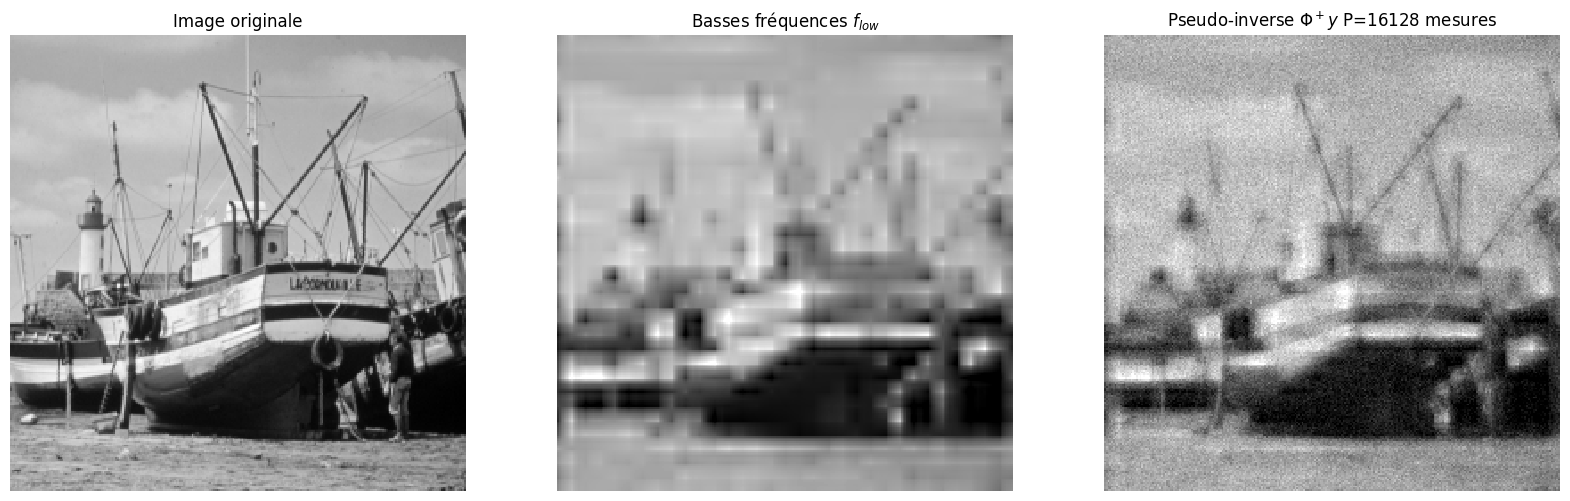

In [18]:
# l'opérateur d'acquisition de mesures
# y = Phi(x0,sigma1,sigma2,P) # retourne un vecteur de mesures de dimension P
# L'opérateur adjoint 
# z = PhiS(y,N,P,sigma1S,sigma2S) renvoie un vecteur dans l’espace des coefficients (dimension N), 
# opérateur d'acquisition de mesures Φ
x_rec = PhiS(y,N,P,sigma1S,sigma2S)
print(f"x_rec.shape : {x_rec.shape}")  # (N,)

# mise à zéro de tous les coéfficient basses fréquences
A = np.ones((coeffs_arr.shape))  
A[0:coeffs_slices[0][0].stop, 0:coeffs_slices[0][1].stop] = 0

# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]

# 3. Reconstruire l'image complète en appliquant les coeffcient issus de la pseudo-inverse
fw_rec = coeffs_arr.flatten().copy()
fw_rec[I0] = x_rec                   # replacer les coefficients high-pass

fw_rec_2d = fw_rec.reshape(coeffs_arr.shape)

print(f"coeffs_arr : {coeffs_arr.shape}, fw_rec_2d : {fw_rec_2d.shape}")
print(f"fw_rec : {fw_rec.shape}, coeffs_slices : {len(coeffs_slices)}") 

# Reconstruire depuis les coefficients d'ondelettes
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, coeffs_slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet='db2', mode='periodization')

# 4. Affichage
plt.figure(figsize=(20, 15))
imageplot(clamp(f0),    'Image originale',                            [1, 3, 1])
imageplot(clamp(f_low), r'Basses fréquences $f_{low}$',               [1, 3, 2])
imageplot(clamp(f_rec), f'Pseudo-inverse $\Phi^+ y$ P={P} mesures',   [1, 3, 3])
plt.show()

- `Figure 1 : Image nette,` avec tous les détails contours nets, textures visibles
- `Figure 2 : Image floue,` contours lissés, détails perdus, seule l'enveloppe générale est visible
- `Figure 3 : Image bruitée,` structure reconnaissable mais granuleuse, contours visibles mais bruités

`Interprétation :` 
- Reconstruction par pseudo-inverse $\Phi^+ y = \Phi^* y$ avec P = 3840 mesures, 25% des N = 15360 coefficient HF. 
- La structure du bateau est reconnaissable, ce qui montre que l'information essentielle a été capturée. 
- Mais il y a du bruit car la pseudo-inverse $\Phi^*$ est une reconstruction naïve qui ne tient pas compte de la parcimonie de $x_0$.


### __`Reconstruction par CS à l'aide de l'algorithme Douglas-Rachford`__
__`Principe`__
Ce problème favorise les solutions parcimonieuses grâce à la norme $\ell^1$, qui permet de retrouver $x_0$ même avec beaucoup moins de mesures que de coefficients.
_`À partir des mesures parcimonieuses hautes fréquences`_ 
- $ y = \Phi x_0$ reconstruire le signal origine $x_0\in\mathbb{R}^N$ en résolvant le problème de minimisation 
   - $x_0$ les coefficients hautes fréquences,
   - $\Phi$ opérateur d'extration de mesures (Compress Sensing)
   - $y$ mesures parcimonieuses (matrice x vecteur)
- $min_{x \in \mathbb{R}^N}||x||_1$ sous contrainte $\Phi x = y$ où $\Phi \in \mathbb{R}^{P \times N}$ avec $P \ll N$, 

  - N = le nombre de pixels dans l'image
  - P = N / 4 nombre de mesures requis par les contraintes Shanon-Nyquist 
_`Décomposition du problème`_
Le problème de la forme $\min_x F(x) + G(x)$ est alors $\min_x \iota_{\mathcal{C}}(x) + ||x||_1$
- $F(x) = \iota_{\mathcal{C}}(x)$ où $\mathcal{C} = \{x \mid \Phi x = y\}$ est l’ensemble des vecteurs compatibles avec les mesures.
   - $\begin{cases}  F(x) = 0 \text{ si } \Phi x = y \\ F(x)=+\infty \text{ sinon } \end{cases}$

- $G(x) = ||x||_1$ => pénalise la norme $\ell1$ et favorise la parcimonie => $G(x) = ||x||_1 = \sum|x_i|$
  - $G(x)=\lambda||x||_1$ (sparsité $\ell1$ sur les HF).
_`Schéma standard de Douglas-Rachford`_
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1}-z_k) - x_{k+1}) \end{cases}$
 où :
- $\text{prox}_{\gamma G}$ seuillage doux 
  - $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
- $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$
  - $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
    - $\gamma > 0$ pas de régularisation
    - $\mu \in (0, 2)$ paramètre de relaxation

##### __`Exercice 3:`__ 
 - Implémenter les opérateurs proximal et proximal réfléchi de $F$ et $G$.
- Retrouver $x$ à partir de $y = \Phi x_0$ avec  P = N/4, c.a.d. 25% des coefficients de $x_0$.
  - _`on connaît y et x0`_
  - _`retrouver x à partir de y et x0`_
__Problème initial :__

In [19]:
print("len(x0), le nombre de coefficients ondelettes haute fréquence de l'image N =",len(x0))
print("len(x0)/4 :",len(x0)/4," nombre de mesures y.shape :",y.shape)

len(x0), le nombre de coefficients ondelettes haute fréquence de l'image N = 64512
len(x0)/4 : 16128.0  nombre de mesures y.shape : (16128,)



__Comment on vérifie ?__
Dans le contexte du TP (exceptionnelle) on connaît $x_0$ donc on peut comparer la reconstruction avec l'original.  
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$

In [20]:
# Opérateurs proximaux
prox_G = lambda x,gamma: np.sign(x) * np.maximum(np.abs(x) - gamma, 0)  # seuillage doux
prox_F = lambda x,y,sigma1,sigma2,P,N,sigma1S,sigma2S: x + PhiS(y-Phi(x,sigma1,sigma2,P),N,P,sigma1S,sigma2S)

### __`Exercice 4`__
Implémenter l'algorithme Douglas-Rachford. Conserver l'évolution des traces $\ell^1$ norm $G(x_k)$.

__`Rappel : Schéma de Douglas-Rachford`__
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1}-z_k) - x_{k+1}) \end{cases}$
 - où :
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
   - $\gamma > 0$ pas de régularisation
   - $\mu \in (0, 2)$ paramètre de relaxation

In [ ]:
# Stocker la norme L1 à CHAQUE itération
L1_history = []  # liste vide pour stocker les valeurs
residu_history  = []
N = len(x0)
niter=10000
gamma = 4e-1
mu = 5e-3
# ✅ 
z = np.zeros(N)
x_tmp = np.zeros(N)
for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,sigma1,sigma2,P,N,sigma1S, sigma2S) - x)
    x_tmp = x.copy()
    if k % 300 == 0:
       residu_history.append(np.linalg.norm(Phi(x, sigma1, sigma2, P) - y))
       L1_history.append(np.sum(np.abs(x_tmp)))   # ← stocker G(x_k) = ||x||₁

# ── Tracé ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Fidélité aux mesures
axes[0].plot(residu_history, 'r-', linewidth=1.5)
axes[0].set_title(r'Fidélité : $\|\Phi x_k - y\|$', fontsize=8)
axes[0].set_xlabel('itération $k$', fontsize=8)
axes[0].set_ylabel('résidu', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)  # abscisse
axes[0].tick_params(axis='y', labelsize=8)  # ordonnée
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Parcimonie
axes[1].plot(L1_history, 'b-', linewidth=1.5)
axes[1].set_title(f'Évolution de la norme $\\ell^1$ : $G(x_k) = ||x_k||_1$\n' f'Convergence vers {L1_history[-1]:.4f}', fontsize=8)
axes[1].set_xlabel('itération $k$', fontsize=8)
axes[1].set_ylabel(r'$||x_k||_1$', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)  # abscisse
axes[1].tick_params(axis='y', labelsize=8)  # ordonnée
axes[1].grid(True, alpha=0.3)

« La norme $\ell1$ de la solution augmente d’abord rapidement, le schéma activant des coefficients pour satisfaire les contraintes de mesure, puis se stabilise autour de 1561. 

Cette forme montée‑puis‑plateau est typique d’une convergence de Douglas–Rachford vers une solution parcimonieuse. »

`Fidélité des mesures :` 
- Le résidu décroît de manière monotone et rapide en échelle logarithmique, de ~10¹ à ~10⁻⁶. 
- Cela confirme que l'algorithme converge vers une solution qui respecte parfaitement les mesures ($\Phi x \approx y$).

`Parcimonie : ` 
- La norme $\ell^1$ converge rapidement vers ~1000, mais ne coïncide pas avec $||x_0||_1 = 1521$. 
- Cela suggère que Douglas-Rachford trouve une solution plus parcimonieuse que $x_0$ elle-même.





In [ ]:
# Comparaison avec la pseudo-inverse
x_rec = PhiS(y,N,P,sigma1S,sigma2S)
# Comparaison
print("Comparaison Douglas-Rachford vs Pseudo-inverse")
print(f"Erreur Douglas Rachford ||x_DR  - x0|| = {np.linalg.norm(x_tmp - x0):.6f}") # Douglas-Rachford
print(f"Erreur Pseudo inverse   ||x_rec - x0|| = {np.linalg.norm(x_rec - x0):.6f}") # Pseudo-inverse
print(f"Gain Pseudo-inverse / Douglas Rachford = {np.linalg.norm(x_rec - x0)/np.linalg.norm(x_tmp-x0):.2f} signifie que Douglas Rachford est meilleur")

# Normalisé par ||x0||
print(f"Erreur relative Douglas-Rachford = {np.linalg.norm(x_tmp - x0)/np.linalg.norm(x0):.4f}")
print(f"n: {n}, Erreur relative Pseudo-inverse Moore-Penrose => Φ* = {np.linalg.norm(x_rec - x0)/np.linalg.norm(x0):.4f}")

### __`Exercice 5`__
Afficher l'image reconstruite à partir des P0 mesures et des P mesures CS.
- Mesures basse fréquence :  $P0 = (n/2^{k0})^2$  (coefficient LL de l'image ondelette)
- Mesures haute fréquence :  $P  = N/4$         (mesures CS via Douglas-Rachford)
Le nombre total de mesures utilisées  :  $P+P0$

Il reste à vérifier si l’image reconstruite correspondante (LL + HF_CS), l’erreur $||f_{combined} −f0||$ ou le PSNR, pour vérifier que cette solution « stable » est aussi visuellement satisfaisante.

In [ ]:
fw_rec = coeffs_arr.flatten().copy()   # contient LL + HF originaux
fw_rec[I0] = z                         # tu remplaces tous les HF par z
fw_rec_2d = fw_rec.reshape(coeffs_arr.shape)
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, coeffs_slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet='db2', mode='periodization')

In [ ]:
# 4. Affichage
plt.figure(figsize=(20, 15))
imageplot(clamp(f0),    'Image originale',                        [1, 2, 1])
imageplot(clamp(f_rec), f'Reconstruction CS Douglas Bradford',   [1, 2, 2])
plt.show()

Le fait que l’image de droite soit ultra bruitée signifie pas que la recomposition est fausse, mais que le vecteur $z$ produit par Douglas–Rachford ne ressemble pas à des coefficients d’ondelettes « réalistes » pour cette image. 
 - il contient beaucoup d’énergie haute fréquence non structurée (comme un bruit), et 
 - quand on injecte ce $z$ dans les HF, on ajoute du bruit sur toute l’image, par‑dessus les LL d’origine.

La chaîne « LL d’origine + HF_CS → waverec2 » est correcte
 - la reconstruction CS via le modèle $min||x||_1 $, $Φx=y$ 
 - avec cette opérateur $Φ$ ne donne pas de bons coefficients hautes fréuences.

Comparaison, 
 - DR converge numériquement (norme $\ell1$ se stabilise),
 - sur cet opérateur d’acquisition, la solution parcimonieuse trouvée dans l’espace des HF 
 - ne correspond pas à des détails d’image pertinents, ce qui produit une reconstruction très bruitée,
 - l’approche « P0 + P » est plus convaincante quand on reconstruit dans la base ondelette complète 
 - avec ISTA/FISTA, plutôt que sur les seuls HF avec ce modèle CS.

In [ ]:
L1_history = []  # liste vide pour stocker les valeurs
N = len(x0)
niter=10000
gamma = 5e-5
mu = 2e-3
# ✅ 
z = np.zeros(N)
x_tmp = np.zeros(N)
for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,sigma1,sigma2,P,N,sigma1S, sigma2S) - x)
    x_old = x.copy()
    if k % 300 == 0:
       L1_history.append(np.sum(np.abs(x_old)))   # ← stocker G(x_k) = ||x||₁
x_CS = x_old.copy()

# Parcimonie
fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.plot(L1_history, 'b-', linewidth=1.5)
axes.set_title(f'Évolution de la norme $\\ell^1$ : $G(x_k) = ||x_k||_1$\n' f'Convergence vers {L1_history[-1]:.4f}', fontsize=8)
axes.set_xlabel('itération $k$', fontsize=8)
axes.set_ylabel(r'$||x_k||_1$', fontsize=8)
axes.tick_params(axis='x', labelsize=8)  # abscisse
axes.tick_params(axis='y', labelsize=8)  # ordonnée
axes.grid(True, alpha=0.3)

In [ ]:
# 3.2 Coefficients combinés : LL d'origine + HF reconstruits
fw_combined = coeffs_arr.flatten().copy()  # contient LL + HF originaux
fw_combined[I0] = x_CS                     # remplace à partir des indice IO, les valeurs HF par CS

fw_combined_2d = fw_combined.reshape(coeffs_arr.shape)

# 4. Reconstruction image complète
coeffs_combined = pywt.array_to_coeffs(fw_combined_2d, coeffs_slices, output_format='wavedec2')
f_combined = pywt.waverec2(coeffs_combined, wavelet='db2', mode='periodization')

In [ ]:
# 5. Comparer avec la reconstruction CS seule (sans P0)
fw_HFCSBR_only = np.zeros_like(coeffs_arr).flatten() 
fw_HFCSBR_only[I0] = x_CS
fw_HFCSBR_only_2d = fw_HFCSBR_only.reshape(coeffs_arr.shape)
coeffs_CS_only = pywt.array_to_coeffs(fw_HFCSBR_only_2d, coeffs_slices, output_format='wavedec2')
f_CSHFBR_only = pywt.waverec2(coeffs_CS_only, wavelet='db2', mode='periodization')

# =================================================================
# Affichage
# =================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 17))

# Rangée 1 : Image reconstruite
axes[0, 0].imshow(clamp(f0), cmap='gray')
axes[0, 0].set_title(f'Image originale $f_0$', fontsize=13)
axes[0, 0].axis('off')

axes[0, 1].imshow(clamp(f_CSHFBR_only), cmap='gray')
axes[0, 1].set_title(f'reconstruction Douglas-Rachford CS sans basse fréquences', fontsize=13)
axes[0, 1].axis('off')

axes[0, 2].imshow(clamp(f_combined), cmap='gray')
axes[0, 2].set_title(f'reconstruction Douglas-Rachford CS HF + BF', fontsize=13)
axes[0, 2].axis('off')

# Rangée 2 : Erreurs
err_CS_only = np.abs(f_CSHFBR_only - f0)
err_combined = np.abs(f_combined - f0)

im1 = axes[1, 0].imshow(clamp(f_low), cmap='gray')
axes[1, 0].set_title(f'Image sans coefficients hautes fréquences', fontsize=13)
axes[1, 0].axis('off')

im2 = axes[1, 1].imshow(err_CS_only, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].set_title(f'reconstruction Douglas-Rachford CS sans basse fréquences\nErreur CS seul ||f_CS - f0|| = {np.linalg.norm(f_CSHFBR_only-f0):.4f}', fontsize=13)
axes[1, 1].axis('off')

im3 = axes[1, 2].imshow(err_combined, cmap='hot', vmin=0, vmax=0.5)
axes[1, 2].set_title(f'reconstruction Douglas-Rachford\nCS Erreur CS + P0 ||f_combined - f0|| = {np.linalg.norm(f_combined-f0):.4f}', fontsize=13)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# =================================================================
# Comparaison quantitative
# =================================================================
print(f"\n=== Comparaison quantitative ===")
print(f"PSNR f_CS_only  : {20*np.log10(1/np.linalg.norm(f_CSHFBR_only-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_combined : {20*np.log10(1/np.linalg.norm(f_combined-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_low      : {20*np.log10(1/np.linalg.norm(f_low-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"\n||f_CS_only - f0||   : {np.linalg.norm(f_CSHFBR_only-f0):.4f}")
print(f"||f_combined - f0||  : {np.linalg.norm(f_combined-f0):.4f}")
print(f"n: {n}, ||f_low - f0||       : {np.linalg.norm(f_low-f0):.4f}")

### `Synthèse`
- Les coefficients basse fréquence (P0) sont indispensables pour la structure globale et une bonne approximation de l’image.  
- Les coefficients haute fréquence, reconstruits par CS via Douglas–Rachford, apportent des détails mais aussi beaucoup de bruit dans cette configuration.  
- La combinaison P0 + P donne une image acceptable mais bruitée, tandis que **P seul** (CS sur HF uniquement) ne suffit pas du tout.

__`On peut en conclure :`__
- que l’algorithme Douglas–Rachford sur les hautes fréquences converge numériquement (norme $\ell1$ stabilisée),  
- avec l’opérateur $\Phi$, la solution parcimonieuse retrouvée reste très bruitée,  
- c'est la présence des LL exacts (P0) qui sauve la qualité perceptuelle de la reconstruction.

## __`Reconstruction CS avec Parcimonie par Blocs`__
#### __`1. Qu'est-ce que la reconstruction avec parcimonie par bloc`__
Afin d'améliorer la reconstruction CS avec parcimonie $\large \ell^1$ on passe parcimonie structurée par blocs qui consiste à  : 
- regrouper la position des coefficients en blocs de $w×w$ pixels, par la découpe des indices {1,…,N} en blocs disjoints $B_k$, 
- ensuite pénaliser la somme des normes $\ell_2$ de ces groupes par :  
  - $G(x)=\sum_k ||x_{B_k}||_2$
    - si l’image un vecteur x, un indice correspond à la position d’un pixel.
    - un indice $i$ désigne la position d’un coefficient dans le vecteur $x\in \mathbb{R}^N$ 
    - $(B_{k})_k$ est une partition (segmentation disjointe) de l'ensemble d'indices ${1,…,N}$ 
    - $x_{B_k}=\{x_i\}_{i \in B_k} \in \mathbb{R}^{∣B_k∣}$ contient les coefficients appartenant au bloc $k$, 
    - $\large \ell_{2,1}$ est la norme, $\ell_{2}$ à l’intérieur de chaque bloc, puis somme (norme $\ell_{1}$) sur les blocs. 
$$||x||_{2,1} = \sum_k||xB_k||_2$$
_`1. L'opérateur proximal bloc`_
 - $\forall k,\quad \operatorname{Prox}_{\gamma G}(x)_{B_k}=\begin{cases}\left(1 - \dfrac{\gamma}{\|x_{B_k}\|_2}\right) x_{B_k} & \text{si } \|x_{B_k}\|_2 > \gamma,\\ 0 & \text{sinon.} \end{cases}$

Et la version coordonnée :
- $ \forall k, \forall m \in B_k ,\quad \text{(Prox}_{\gamma G}(x))_m = \max(0, 1−\large \frac{\gamma}{||xB_k||_2} )x_m$

_`2. Partie ISTA/FISTA`_ 
ISTA/FISTA, méthode d’optimisation proximale de premier ordre capable de résoudre des problèmes du type :  
- $min_x F(x)=f(x)+g(x)$, où 

  - f est la partie **lisse** (smooth) différentiable partout avec un gradient $∇f$ Lipschitz gradient et 
  - g est la partie **non lisse** possiblement non différentiable et convexe 
    - pénalisation lasso $\ell_1$, fonction indicatrice d’un ensemble, norme \ell_{2,1} , TV, etc.  

`Un algorithme proximal type ISTA/FISTA fait, à chaque itération k.`
__`1°) Pas de gradient sur le terme de données :`__ 
- $f(x)= \frac{1}{2}||\Phi x−y||_2^2 , \qquad \nabla f(x) = \Phi^*(\Phi x - y) $, 
mise à jour intermédiaire avec un pas de $\gamma$ : 
 - $x^{k+\frac{1}{2}} = x^k - \gamma \nabla f(x^k)$

   - $\Phi x$ = opérateur direct (par exemple $A\Phi^{−1}x$).
   - $f(x)= \frac{1}{2}||\Phi x−y||_2^2$  = terme de données.
__`2°) Pas de proximal bloc sur G`__
- $x^{k+1} =\text{Prox}_{γλG}(x^{k+\frac{1}{2}})$
_Il s'écrit sous la forme :_
- $\forall m \in B_i \text{ , Prox}_{γG}(x)_i = \max(0,1 − \frac{γ}{||x_{B_i}||})x_i$ 
    -  $w × w$ : blocs uniformes pixels. 
    - $B_i ⊂ \{1,…,N\}$ l’ensemble des indices du bloc numéro i.
    - $m \in B_i$ un indice, il désigne un coefficient de ce bloc (un pixel du vecteur x)
- c’est l'opérateur de seuillage doux : 
   - si la norme du bloc est petite, on met tout le bloc à 0, 
   - sinon on contracte tout le bloc d'un facteur $1−\frac{γ}{||x_{B_i}||_2}$  


`C'est la préparation du seuillage par blocs :` 
- on sait quels coefficients CS appartiennent à chaque bloc.  
- ce qui permettra d'appliquer l'opérateur proximal $\text{Prox}_{γG}$ bloc par bloc.

Pour $w = 4$, chaque bloc est un carré de 16 pixels :
- Le seuillage proximal par bloc calcule : $\text{Prox}_{γG}(x)_i=max(0,1−\large \frac{γ}{||x_{B_i}||})x_i$
  - on a besoin de tous les $w^2$ coefficients du bloc pour calculer $||x_{B_i}||$. 
  - si un pixel manque → le bloc est inutilisable → on le rejette.
_`Exercice recoder l’image:`_ 
 - $q^2$ représente une grande liste de blocs, 
 - chaque bloc décrit par $w^2$ indices de lignes/colonnes. 
 Cette structure sert à exprimer la pénalisation en parcimonie par blocs (norme $\ell_{2,1})$:
 - construire un opérateur de reconstruction bloc‑par‑bloc (prox, mise à jour, etc.), 
 - utiliser les mesures IRM pour contraindre certains pixels à rester égaux aux données mesurées.  

_`Retirer le bloc qui sort de l'image`_  
- Tous les blocs $w×w$ - ⬇️
- blocs débordant hors image - ⬇️ (filtre précédent sur $X+dX > n$)    
- blocs avec pixels non mesurés - ⬇️ (ce filtre)
- Blocs valides et complets → prêts pour le seuillage proximal par blocs

`Afficher la structure en blocs dans l’espace des coefficients`
- pour afficher la structure une image même fictive suffit et la façon dont les indices sont construits.
  - une image de taille n×n (ou bien un tableau numpy génèré),
  - la liste des pixels observés IRM, donc rows_IRM, cols_IRM,
  - la carte qui code les indices de mesures (1..N) sur l’image,
  - la décomposition en blocs via X, Y, dX, dY,
  - le filtrage, des indices de mesures par bloc.
- pour vérifier la structure des blocs dans l’espace des coefficients : 
  - à qui appartient à quel bloc, 
  - quels indices sont groupés, 
- pour tester le code de prox on peut travailler avec un vecteur de mesures fictif $y$, 
- la structure des blocs ne dépend pas du contenu de $y$, seulement de la géométrie des indices.
- Les mesures CS “réelles” interviennent lorsque l'on lie cette structure à l’équation $y=Ax$

In [ ]:
print((256**2 // 2),3*(256**2 // 2) // 4)

In [ ]:
import numpy as np

# 1. Paramètres globaux
n = f0.shape[0]          # image n x n
w = 2                    # taille des blocs w x w
N = 3 * n * n // 4       # 75 % de pixels mesurés

# 2. IRM Indices des pixels Réellement Mesurés (0-base)
IRM = np.random.choice(n*n, N, replace=False)
rows_IRM = IRM // n # indices de ligne
cols_IRM = IRM %  n # indices de colonne

# 3. Masque image de mesure M_img (bool)
M_img = np.zeros((n, n), dtype=bool)
M_img[rows_IRM, cols_IRM] = True   # True = pixel mesuré

# 4. Grille de blocs réguliers (1-base)
v  = np.arange(1, n+1, w)        # coins supérieurs-gauches des blocs
dv = np.arange(0, w)             # décalages internes
print("v.shape :", v.shape, "dv.shape :", dv.shape)

dX, dY, X, Y = np.meshgrid(dv, dv, v, v, indexing='ij')
print("X.shape :", X.shape, "dX.shape :", dX.shape)

q = X.shape[2]                   # nombre de blocs par dimension = n // w

# 5. Passage en liste de blocs (w^2, q^2)
X  = X.reshape(w*w, q*q)
Y  = Y.reshape(w*w, q*q)
dX = dX.reshape(w*w, q*q)
dY = dY.reshape(w*w, q*q)

print("X.reshape : ", X.shape, "X.shape[2] = q :", q, "  q*q :", q*q)

# 6. Filtrage géométrique : blocs entièrement dans l'image
# (ici, tous les blocs réguliers sont dans l'image si n est multiple de w,
# mais on garde ce test pour généraliser
hors_image = (X + dX > n) | (Y + dY > n)   # 1-base
blocs_hors = (hors_image.sum(axis=0) > 0) # si >0 => au moins un pixel hors de l'image

valide_geo = ~blocs_hors
print("nb blocs valides géométriquement :", valide_geo.sum())

X  = X[:, valide_geo]
Y  = Y[:, valide_geo]
dX = dX[:, valide_geo]
dY = dY[:, valide_geo]

# 7. Indices 0-base des pixels des blocs valides
row = (X + dX - 1).astype(int)   # 0..n-1
col = (Y + dY - 1).astype(int)

print("nb de row valides row.shape : ", row.shape)  # (w*w, nb_blocs_valides)
print("nb de col calides col.shape : ", col.shape)  # (w*w, nb_blocs_valides)

# 8. Masque de mesure par bloc M_blocs (w^2, nb_blocs_valides)
M_blocs = M_img[row, col]
print("Masque de mesure M_blocs.shape :", M_blocs.shape)

# 9. (Optionnel) Intensités par bloc I_blocs, si tu en as besoin
I_blocs = f0[row, col]           # même shape que M_blocs

# 10. Sélection des blocs complètement mesurés
# M_blocs == 0 met True exactement là où M_blocs vaut 0, False ailleurs.
blocs_incomplets = (M_blocs == 0).sum(axis=0) > 0   # True = au moins un pixel non mesuré
print("nb blocs blocs_incomplets :", blocs_incomplets.sum(), "sur", blocs_incomplets.shape)
complets = ~blocs_incomplets

print("nb blocs complets :", complets.sum(), "sur", M_blocs.shape[1])

M_blocs = M_blocs[:, complets]
I_blocs = I_blocs[:, complets]
row     = row[:, complets]
col     = col[:, complets]

print("M_blocs :", M_blocs.shape)
print("I_blocs :", I_blocs.shape)
print("row :", row.shape)
print("col :", col.shape)


Définir l'énergie 

In [ ]:
G = lambda x,I: np.linalg.norm(x[I], axis=0).sum()

__`Intégrer par blocs un prox`__ $\ell_{2,1}$
- dans notre cas $\ell_{2,1}$, on remplace le seuillage doux scalaire par le prox bloc écrit plus haut, 
- utiliser la structure de blocs définie a priori sur les coefficients d’une base, 
- ou directement en pixels si on regroupe les indices de x par blocs.

#### __`1. Construire les groupes`__
Un bloc est défini tel que $B_k = \{ I_{k,j} \}_{j=1}^{w^2}$.
- $B_k$ est l’ensemble des indices (dans le vecteur $x∈R^N$ ) correspondant aux pixels du bloc i. 
- C’est cohérent avec la manière dont on note des ensembles d’indices en group lasso / blocs

Rappel :
- $I[k,j]$ est l'indice de mesure entre ($1$ et $N$) du $j_{ième}$ pixel du bloc $k$ dans le vecteur $x$ (après filtrage il n’y a plus de 0).
- on veut des groupes d’indices pour un vecteur $x \in R^N$.
- $groups[k]$ est un tableau de longueur $w^2$ contenant les indices des coefficients $x$ appartenant au bloc $k$, 
  - c’est‑à‑dire groups[k]=$B_k$

Note : 
- On note $\Phi$ la matrice de mesure ($\Phi \in R^{m×N}$), et on a $y = \Phi 𝑥_{true}$
- Dans le code, on note $\Phi$ par A et on calcule y = A @ x_true.

In [ ]:
# 1) Image vraie
f0_norm = f0 / 255.0
x_true = f0_norm.ravel()
N=len(x_true)
sigma = 0.02 # bruit modéré
m = N // 4

w2, nb_blocs = row.shape
groups = []

for k in range(nb_blocs):
    r = row[:, k]
    c = col[:, k]
    idx = r * n + c          # indices 0-based des 4 pixels du bloc k dans x
    groups.append(idx.astype(int))

In [ ]:
print("f0.shape        :", f0.shape)
print("n               :", n)
print("N = n*n         :", n*n)
print("N = x_true.size :", N)
print("A.shape         :", A.shape)

print("Nombre de blocs :", len(groups))
print("min group index :", min(g.min() for g in groups))
print("max group index :", max(g.max() for g in groups), "versus N-1 =", N-1)

_`1. L'opérateur proximal bloc`_
 - $\forall k,\quad \operatorname{Prox}_{\gamma G}(x)_{B_k}=\begin{cases}\left(1 - \dfrac{\gamma}{\|x_{B_k}\|_2}\right) x_{B_k} & \text{si } \|x_{B_k}\|_2 > \gamma,\\ 0 & \text{sinon.} \end{cases}$

Et la version coordonnée :
- $ \forall k, \forall m \in B_k ,\quad \text{(Prox}_{\gamma G}(x))_m = \max(0, 1−\large \frac{\gamma}{||xB_k||_2} )x_m$

In [ ]:
def prox_l21_group(x, groups, lam):
    x_out = x.copy()
    for idx in groups:
        bloc = x[idx]               # sous-vecteur du bloc
        nrm_bloc = np.linalg.norm(bloc, 2)
        if nrm_bloc > lam:
            factor = max(0.0, 1.0 - lam / nrm_bloc) 
            x_out[idx] = factor * bloc
        else:
            x_out[idx] = 0.0
    return x_out

#### `Étape d’optimisation`
_`Dans le proximal gradient (ISTA), on met à jour`_:
 - $x^{k+1}=prox_{step \lambda G} (x^k − grdStep \nabla f(x^k))$
_`Avec`_
- $f(x)= \frac{1}{2}||A x−y||_2^2 , \qquad \nabla f(x) = A^T(A x - y) $, 
Pour que l’algorithme converge, on impose en général que le pas de gradient "grdStep" soit : 
- $0 < grdStep ≤ L$ avec 
- $L = \large \frac{1}{||A||_2^2}$ constante de Lipschitz pour $\nabla f$

In [ ]:
# Cette pénalisation est exactement celle du group lasso : elle encourage des blocs entiers 
# à devenir zéro (sparsité par blocs), plutôt que des coefficients isolés comme avec une l1 classique.
def G_l21(x, groups):
    return sum(np.linalg.norm(x[idx], 2) for idx in groups)

def pg_l21(A, y, x_true, groups, lam, n_iter=50, grdStep=None, verbose=True):
    _, N = A.shape
    if grdStep is None:
        L = np.linalg.norm(A, ord=2)**2
        grdStep = 1.0 / L
    x = np.zeros(A.shape[1])
    errors = []   # pour stocker l'erreur
    At = A.T

    print("A.shape : ",A.shape," y.shape : ",y.shape, " x.shape : ",x.shape)

    for k in range(n_iter):
        r    = A @ x - y
        grad = At @ r
        x_new = prox_l21_group(x - grdStep * grad, groups, grdStep * lam)

        # erreur de reconstruction si x_true est fourni
        if x_true is not None:
            err = np.linalg.norm(x_new - x_true) / np.linalg.norm(x_true)
            errors.append(err)

        x = x_new

        if verbose and (k % 5 == 0 or k == n_iter - 1):
            res_norm = np.linalg.norm(r)
            G = G_l21(x, groups)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | G_l21 = {G:.4e}")

    return x, errors

Normalisation de la matrice de mesure gaussienne et contrôler la taille des colonnes / du gradient.
 - chaque entrée $∼\mathcal N(0,1/m)$, variance $1/m$
 - la norme quadratique moyenne d’une colonne devient $≈1$, $\sum_m$ des $m$ termes de variance $1/m$ → variance totale $≈1$.

In [ ]:
lam = 1e-6 
A = np.random.randn(m, N) / np.sqrt(m)
y = A @ x_true
y = y.astype(np.float32)
x = np.zeros(N)
print("A.shape : ",A.shape," x_true.shape : ",x_true.shape," y.shape : ",y.shape," x.shape : ",x.shape)
x_rec, errors = pg_l21(A, y, x_true, groups, lam, n_iter=300)
img_rec = x_rec.reshape(f0.shape)

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(errors, 'b-', label='erreur relative')
plt.title("Erreur")
plt.xlabel("Itération")
plt.ylabel("Erreur")
plt.legend()          # sans argument
plt.show()

In [ ]:
all_idx = np.concatenate(groups)
print(all_idx.min(), all_idx.max(), len(np.unique(all_idx)))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec, cmap='gray')
plt.title("Reconstruction blocs")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_rec - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def tv_smooth_grad(u, epsilon):
    Gr = grad(u)
    l2 = np.sqrt(np.sum(Gr**2, axis=2))
    den = np.sqrt(epsilon**2 + l2**2)
    P = Gr / den[..., None]
    return -div(P)

In [ ]:

def block_cs_gradient_descent(y, A, shape, lam=0.05, w=4, epsilon=1e-3, tau=0.1, niter=100, x_true=None):

    n1, n2 = shape
    N = n1 * n2
    x = np.zeros(N)
    errors = []
    At = A.T

    for it in range(niter):
        # terme données
        r = A @ x - y
        g_data = At @ r
        # terme régularisation par blocs
        u = x.reshape(n1, n2)
        g_block = tv_smooth_grad(u, epsilon=epsilon).ravel()
        # mise à jour
        x = x - tau * (g_data + lam * g_block)
        # suivi erreur
        if x_true is not None:
            err = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
            errors.append(err)

    return x, errors

In [ ]:
lam = 4e-4 
A = np.random.randn(m, N) / np.sqrt(m)
y = A @ x_true
y = y.astype(np.float32)
x = np.zeros(N)

# Image 256 × 256
n1, n2 = 256, 256
N = n1 * n2  # 65536

# Matrice de mesure : on garde seulement 30% des pixels
m = int(0.3 * N)  # 19661 mesures

x_rec, errors = block_cs_gradient_descent(y, A, shape=(n1, n2), lam=0.05, w=2, epsilon=1e-3, tau=0.1, niter=100, x_true=None)
img_rec = x_rec.reshape(f0.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec, cmap='gray')
plt.title("Reconstruction blocs")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_rec - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

#### `Problème actuel`
On résoud actuellement par descente de gradient : 
- $\min_x \frac{1}{2}\|Ax - y\|_2^2 + \lambda R(x)$ où $R(x)$ est soit la TV lissée, soit la block sparsity.
#### `Méthode ADMM`
ADMM **sépare** le problème en introduisant une **variable auxiliaire** $z$ :
$\min_{x,z} \frac{1}{2}\|Ax - y\|_2^2 + \lambda R(z) \quad \text{tel que} \quad x = z$
__`Le Lagrangien augmenté devient`__ :
$$\large L_\rho(x, z, u) = \frac{1}{2}\|Ax - y\|_2^2 + \lambda R(z) + \frac{\rho}{2}\|x - z + u\|_2^2$$
#### `Algorithme ADMM (slides 155-158)`
L'algorithme alterne entre trois étapes :
1. `Mise à jour de` **$x$** (facile car quadratique) : 
$$\large x^{k+1} = \arg\min_x \frac{1}{2}\|Ax - y\|_2^2 + \frac{\rho}{2}\|x - z^k + u^k\|_2^2$$
2. `Mise à jour de` **$z$** (`opérateur proximal de` **$R$**) : 
$$\large  z^{k+1} = \arg\min_z \lambda R(z) + \frac{\rho}{2}\|x^{k+1} - z + u^k\|_2^2$$
3. `Mise à jour du multiplicateur dual` **$u$** : 
$$\large  u^{k+1} = u^k + x^{k+1} - z^{k+1}$$

### `Avantages` 
##### `Norme TV (slides 164-165)`
- Si $R(x) = \text{TV}(x)$, l'étape 2 devient un **opérateur proximal de la TV** qui a des solutions efficaces connues. 
- C'est **beaucoup plus stable** que ta descente de gradient avec TV lissée.

##### `Norme L1 / block sparsity (slide 158)`
- Si $R(z) = \|z\|_1$ ou block sparsity, l'étape 2 est un **seuillage doux** (soft thresholding) : 
  - $z^{k+1} = \text{soft}(x^{k+1} + u^k, \lambda/\rho)$

C'est **exactement** ce qui manque à notre approche actuelle : 
- au lieu de lisser la norme $\ell2$ par bloc avec $\large \epsilon$, ADMM applique directement le seuillage optimal.

In [ ]:
def block_soft_thresholding(v, shape, threshold, w):
    """
    Seuillage doux par blocs : 
    z_B = max(0, 1 - threshold/||v_B||) * v_B
    """
    n1, n2 = shape
    u = v.reshape(n1, n2)
    
    pad1 = (w - n1 % w) % w
    pad2 = (w - n2 % w) % w
    u_pad = np.pad(u, ((0, pad1), (0, pad2)), mode='reflect')
    n1p, n2p = u_pad.shape
    
    z_pad = np.zeros_like(u_pad)
    
    for i in range(0, n1p, w):
        for j in range(0, n2p, w):
            B = u_pad[i:i+w, j:j+w]
            normB = np.linalg.norm(B)
            
            # Seuillage doux du bloc entier
            if normB > threshold:
                z_pad[i:i+w, j:j+w] = (1 - threshold / normB) * B
            # sinon le bloc reste à zéro
    
    return z_pad[:n1, :n2].ravel()

In [ ]:
import numpy as np

def block_l21_norm(x, shape, w):
    """
    Calcule sum_B ||x_B||_2 pour une partition en blocs w x w.
    Tronque proprement les blocs partiels aux bords si n1 ou n2 ne sont pas multiples de w.
    x: 1D array (N,)
    shape: (n1, n2)
    w: block size (int)
    retourne: float
    """
    n1, n2 = shape
    X = x.reshape(n1, n2)
    total = 0.0

    for i in range(0, n1, w):
        i_end = min(i + w, n1)
        for j in range(0, n2, w):
            j_end = min(j + w, n2)
            block = X[i:i_end, j:j_end]
            total += np.linalg.norm(block.ravel(), 2)

    return float(total)

In [ ]:
import numpy as np
from scipy.sparse.linalg import cg, LinearOperator

def block_cs_admm(
    y, A, shape, lam=0.05, w=4, rho=1.0, niter=100,
    x_true=None, use_cg=True, cg_tol=1e-6, cg_maxiter=200
):
    """
    ADMM pour block sparsity :
        min_x  1/2 ||A x - y||^2 + lam * sum_B ||z_B||_2
        s.c.   x = z

    Paramètres
    ----------
    y      : array, shape (M,)
    A      : array ou opérateur linéaire, shape (M, N)
    shape  : tuple (n1, n2)
    lam    : float
    w      : int Taille des blocs pour block_soft_thresholding
    rho    : float
    niter  : int
    x_true : array, optional Pour suivre l'erreur relative
    use_cg : bool Si True, résout l'étape x par Conjugate Gradient
    cg_tol : float
    cg_maxiter : int

    Retour
    ------
    x : array, shape (N,)
    errors : list
    objvals : list
    """
    n1, n2 = shape
    N = n1 * n2

    x = np.zeros(N, dtype=np.float64)
    z = np.zeros(N, dtype=np.float64)
    u = np.zeros(N, dtype=np.float64)

    At = A.T
    Aty = At @ y

    errors = []
    objvals = []

    if not use_cg:
        AtA = At @ A
        K = AtA + rho * np.eye(N)
        try:
            L = np.linalg.cholesky(K)
            use_cholesky = True
        except np.linalg.LinAlgError:
            use_cholesky = False

    else:
        def matvec(v):
            return At @ (A @ v) + rho * v
        K_op = LinearOperator((N, N), matvec=matvec, dtype=np.float64)

    for it in range(niter):
        rhs = Aty + rho * (z - u)

        # 1) x-update
        if use_cg:
            x, info = cg(K_op, rhs, x0=x, rtol=cg_tol, maxiter=cg_maxiter)
            if info != 0:
                print(f"[it {it}] Avertissement CG, info={info}")
        else:
            if use_cholesky:
                v = np.linalg.solve(L, rhs)
                x = np.linalg.solve(L.T, v)
            else:
                x = np.linalg.solve(K, rhs)

        # 2) z-update
        z = block_soft_thresholding(x + u, shape, lam / rho, w)

        # 3) dual update
        u = u + x - z

        # suivi erreur
        if x_true is not None:
            denom = np.linalg.norm(x_true)
            err = np.linalg.norm(x - x_true) / (denom + 1e-12)
            errors.append(err)

        # suivi objectif
        data_fid = 0.5 * np.linalg.norm(A @ x - y)**2
        reg = block_l21_norm(x, shape, w)
        objvals.append(data_fid + lam * reg)

    return x, errors, objvals

In [ ]:
lam = 5e-3 
w = 4
A = np.random.randn(m, N) / np.sqrt(m)
y = A @ x_true
y = y.astype(np.float32)
x = np.zeros(N)

# Image 256 × 256
n1, n2 = 256, 256
N = n1 * n2  # 65536

x, errors, objvals = block_cs_admm(y, A, shape=(n1, n2), lam=0.05, w=4, rho=1.0, niter=100, x_true=None)
img_rec = x_rec.reshape(f0.shape)

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(errors, 'b-', label='erreur relative')
plt.title("Erreur")
plt.xlabel("Itération")
plt.ylabel("Erreur")
plt.legend()          # sans argument
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec, cmap='gray')
plt.title("Reconstruction blocs")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_rec - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

### __`Parcimonie sur coefficients d’ondelettes ou patchs`__

Nous reformulons la version « parcimonie sur coefficients d’ondelettes globaux », 
 - Puis repassons par une approche vraie par patchs.
 - Appliquons la parcimonie (pas aux pixels), aux coefficients d’ondelettes $\alpha$, avec $x=W^T\alpha$. 
 - On commence par une pénalité $\ell_1$ simple sur les coefficients, 
 - Puis on pourra re‑complexifier (groupes par sous‑bandes, par échelles, etc.).

__`1°) Principe du nouveau modèle`__
 - au lieu de poser : $min_x \frac{1}{2}||A(x)−y||^2_2+λ\sum_i ||x_{g}||_2$
 - on pose $x=W^T\alpha$ (ondelettes orthogonales, par exemple Haar) 
 - on résoud $\min_x \frac{1}{2} ||AW^T\alpha−y||_2^2 +\lambda|\alpha|_1$
 - ensuite on reconstruit l’image avec $x_{rec} =W^T \alpha_{rec} \text{ et => } img_{rec}=reshape(x_{rec})$

La seule différence pratique :
 - on change la variable optimisée ($\alpha$ au lieu de $x$),
 - on remplace prox_l21_blocks par un soft‑thresholding composante par composante sur $\alpha$. 

#### __`2. Code : création opérateurs ondelettes`__

In [ ]:
import pywt

def wv2d_forward(img, wavelet='db2', level=3):
    # décomposition ondelettes 2D
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    # on stocke les shapes pour replier
    coeffs_arr, coeffs_slices = pywt.coeffs_to_array(coeffs)
    return coeffs_arr, coeffs_slices

def wv2d_inverse(coeffs_arr, coeffs_slices, wavelet='db2'):
    coeffs = pywt.array_to_coeffs(coeffs_arr, coeffs_slices, output_format='wavedec2')
    img = pywt.waverec2(coeffs, wavelet=wavelet)
    return img

`Ensuite, on définit les opérateurs linéaires sur les vecteurs 1D (taille N) :`

In [ ]:
# 3) opérateurs
def Wt(alpha,f0):
    # alpha (M,) -> image (n,n)
    coeffs_arr, coeffs_slices = wv2d_forward(f0,wavelet='db2', level=3)
    alpha_2d = alpha.reshape(coeffs_arr.shape)
    img = wv2d_inverse(alpha_2d, coeffs_slices)
    return img.ravel()

def W(x,f0):
    # x (N,) -> coeffs (M,)
    img = x.reshape(f0.shape)
    a2d, _ = wv2d_forward(img)   # coeff_slices est identique tant qu'on garde même wavelet/level
    return a2d.ravel()

À ce stade, on travaille encore avec la même matrice de mesure A et le y de mesures sur les pixels.
On ne change pas A ni y, on change seulement la variable d’optimisation.

#### __`3. L'opérateur proximal de G(x) dans le domaine des ondelettes`__
On veut minimiser en $\alpha$ : $\min_x \frac{1}{2} ||AW^T\alpha−y||_2^2 +\lambda|\alpha|_1$
Le gradient de la partie lisse est : $\nabla F_{lisse}(\alpha)=WA^T(AW^T\alpha−y)$

In [ ]:
def grad_alpha(f0,alpha,P,y,sigma1, sigma2,sigma1S, sigma2S):
    x = Wt(alpha,f0)                    # (N,)
    r = Phi(x, sigma1, sigma2, P) - y
    g_x = PhiS(r, N, P, sigma1S, sigma2S)
    print("grad_alpha g_x.shape:", g_x.shape)    
    print("grad_alpha x.shape:", x0.shape)
    print("grad_alpha y.shape:", y.shape)
    print("grad_alpha f0 shape:", f0.shape)
    g_alpha = W(g_x,f0)                 # (M,)
    return g_alpha

In [ ]:
def gradalpha(A,f0,alpha):
    At = A.T
    x = Wt(alpha,f0)           # image vectorisée    
    r = A @ x - y           # résidu dans l'espace des mesures
    g_x = At @ r            # gradient w.r.t x
    g_alpha = W(g_x,f0)        # on reflète dans le domaine ondelettes
    return g_alpha

Et un $prox_{\ell_1}$ simple (soft-thresholding) :

In [ ]:
def soft_threshold(z, tau):
    return np.sign(z) * np.maximum(np.abs(z) - tau, 0.0)

#### __`4. L'opérateur proximal de G(x) en α`__

In [ ]:
def prox_l21_blocks(z, groups, lam):
    z = z.copy()
    for idx in groups:
        bloc = z[idx]
        norm_bloc = np.linalg.norm(bloc)
        if norm_bloc > lam:
            z[idx] = (1 - lam / norm_bloc) * bloc
        else:
            z[idx] = 0.0
    return z

In [ ]:
# COMPARAISON AVE EN DESSOUS 
def G_l21(x, groups):
    return sum(np.linalg.norm(x[idx], 2) for idx in groups)

def pg_l21(A, y, groups, lam, n_iter=100, step=None, verbose=True):
    m, N = A.shape
    if step is None:
        L = np.linalg.norm(A, ord=2)**2
        step = 1.0 / L
    x = np.zeros(N)
    At = A.T

    for k in range(n_iter):
        r    = A @ x - y
        grad = At @ r
        x = prox_l21_blocks(x - step * grad, groups, step * lam)
        if verbose and (k % 10 == 0 or k == n_iter - 1):
            res_norm = np.linalg.norm(r)
            G = G_l21(x, groups)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | G_l21 = {G:.4e}")
    return x

In [ ]:
def pg_l1wavelet(A, f0, y, lam, n_iter=100, step=None, verbose=True):
    # A: m x N, y: (m,)
    m, N = A.shape
    # estimation L : norme de A W^T. On va prendre une borne simple
    if step is None:
        # approximation grossière : ||A||_2^2 comme avant, ça marche en pratique
        L = np.linalg.norm(A, ord=2)**2
        step = 1.0 / L

    coeffs_arr, _ = wv2d_forward(f0)    
    alpha_true = coeffs_arr.ravel()
    # initialisation alpha = 0
    alpha = np.zeros_like(alpha_true)  # même dimension que les coeffs d'ondelettes

    for k in range(n_iter):
        g = grad_alpha(f0,alpha,P,y,sigma1, sigma2,sigma1S, sigma2S)
        alpha = soft_threshold(alpha - step * g, step * lam)

        if verbose and (k % 10 == 0 or k == n_iter - 1):
            x = Wt(alpha,f0)
            r = A @ x - y
            res_norm = np.linalg.norm(r)
            sparsity = np.mean(alpha == 0)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | sparsity(alpha) = {sparsity:.2f}")

    return alpha

In [ ]:
def pg_l1_wavelet(y, f0, lam, P, sigma1, sigma2,sigma1S, sigma2S, n_iter=100, step=None, verbose=True):
    # Ici il n'y a plus A, juste Phi et PhiS implicites
    if step is None:
        # Tu peux estimer L via une puissance itérée sur PhiS∘Phi
        # ou mettre une borne grossière.
        step = 1e-3  # par ex. au début

    coeffs_arr, _ = wv2d_forward(f0)    
    alpha_true = coeffs_arr.ravel()
    alpha = np.zeros_like(alpha_true)

    for k in range(n_iter):
        g = grad_alpha(f0,alpha,P,y,sigma1, sigma2,sigma1S, sigma2S)
        alpha = soft_threshold(alpha - step * g, step * lam)

        if verbose and (k % 10 == 0 or k == n_iter - 1):
            x = Wt(alpha,f0)
            r = Phi(x, sigma1, sigma2, P) - y
            res_norm = np.linalg.norm(r)
            sparsity = np.mean(alpha == 0)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | sparsity(alpha) = {sparsity:.2f}")

    return alpha

In [ ]:
alpha_true = coeffs_arr.ravel()
M = alpha_true.size
N = f0.size
print("N =", N, "M =", M)
sparsity = np.mean(alpha_rec == 0)
print("sparsity(alpha_rec) =", sparsity)

In [ ]:
# opérateur d'acquisition ou de mesures comprimées
coeffs_arr, coeffs_slices = wv2d_forward(f0)    
alpha_true = coeffs_arr.ravel()
# initialisation alpha = 0
alpha = np.zeros_like(alpha_true)  # même dimension que les coeffs d'ondelettes

# l'opérateur d'acquisition de mesures
y = Phi(alpha,sigma1,sigma2,P)
# L'opérateur adjoint 
z = PhiS(y,N,P,sigma1S,sigma2S)
print(f"n: {n}, phiS.shape : {z.shape},\nz : {z}")



x = Wt(alpha,f0)           # image vectorisée
#r = A @ x - y           # résidu dans l'espace des mesures

x0 = f0.ravel()
#y = Phi(x0,sigma1,sigma2,P)
#y  = A @ x0
print("A @ x.shape:", (A @ x).shape)
print("A.shape:", A.shape)
print("P :", P)
print("x0.shape:", x0.shape)
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("A @ x0 shape:", (A @ x0).shape)
print("f0 shape:", f0.shape)

In [ ]:
lam = 0.01

# opérateur d'acquisition ou de mesures comprimées
y = Phi(alpha,sigma1,sigma2,P)

alpha_rec = pg_l1_wavelet(y, f0, lam, P, sigma1, sigma2,sigma1S, sigma2S, n_iter=100, step=None, verbose=True)
x_rec = Wt(alpha_rec,f0)
img_rec = x_rec.reshape(f0.shape)

In [ ]:
# 4. Affichage
plt.figure(figsize=(15, 10))
imageplot(clamp(f0),'Image originale', [1, 2, 1])
imageplot(clamp(img_rec),'reconstruction CS\n avec parcimonie par bloc', [1, 2, 2])
plt.show()

In [ ]:
def grad_alpha(alpha, y, P, sigma1, sigma2, sigma1S, sigma2S):
    # alpha -> x -> Phi(x) -> r -> PhiS(r) -> gradient w.r.t alpha
    x = Wt(alpha)                               # (N,)
    r = Phi(x, sigma1, sigma2, P) - y           # (P,)
    g_x = PhiS(r, N, P, sigma1S, sigma2S)       # (N,)
    g_alpha = W(g_x)                            # (M,)
    return g_alpha

In [ ]:
def pg_l1_wavelet(y, lam, P, sigma1, sigma2, sigma1S, sigma2S,
                  n_iter=100, step=None, verbose=True):
    # y : (P,)
    if step is None:
        step = 1e-3   # petit pas pour commencer

    alpha = np.zeros_like(alpha_true)

    for k in range(n_iter):
        g = grad_alpha(alpha, y, P, sigma1, sigma2, sigma1S, sigma2S)
        alpha = soft_threshold(alpha - step * g, step * lam)

        if verbose and (k % 10 == 0 or k == n_iter - 1):
            x = Wt(alpha)
            r = Phi(x, sigma1, sigma2, P) - y
            res_norm = np.linalg.norm(r)
            sparsity = np.mean(alpha == 0)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | sparsity(alpha) = {sparsity:.2f}")

    return alpha

In [ ]:
import pywt
import numpy as np

# 0) Image de référence (2D)
print("f0.shape =", f0.shape)   # doit afficher (256, 256)

# 1) Décomposition ondelette une seule fois
def wv2d_forward(img, wavelet='db2', level=3):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    coeffs_arr, coeffs_slices = pywt.coeffs_to_array(coeffs)
    return coeffs_arr, coeffs_slices

def wv2d_inverse(coeffs_arr, coeffs_slices, wavelet='db2'):
    coeffs = pywt.array_to_coeffs(coeffs_arr, coeffs_slices, output_format='wavedec2')
    img = pywt.waverec2(coeffs, wavelet=wavelet)
    return img

coeffs_arr, coeffs_slices = wv2d_forward(f0)
alpha_true = coeffs_arr.ravel()
M = alpha_true.size
N = f0.size
print("N =", N, "M =", M)

def Wt(alpha):
    # alpha (M,) -> x (N,)
    alpha_2d = alpha.reshape(coeffs_arr.shape)
    img = wv2d_inverse(alpha_2d, coeffs_slices)
    return img.ravel()

def W(x):
    # x (N,) -> alpha (M,)
    img = x.reshape(f0.shape)
    a2d, _ = wv2d_forward(img)
    return a2d.ravel()

In [ ]:
P = N // 4
x0 = f0.ravel()
y  = Phi(x0, sigma1, sigma2, P)

# test direct de PhiS
r = y.copy()   # (P,)
g_x = PhiS(r, N, P, sigma1S, sigma2S)

print("N attendu :", N)
print("taille g_x :", g_x.size)

In [ ]:
r = y.copy()  # (P,)

z0 = uparrow(r, N, P)
print("Après uparrow :", z0.size)   # doit être N = 65536

z1 = Sinv_2(z0, sigma2S)
print("Après Sinv_2  :", z1.size)

z2 = Cinv(z1)
print("Après Cinv    :", z2.size)

z3 = Sinv_1(z2, sigma1S)
print("Après Sinv_1  :", z3.size)

In [ ]:
# mesures compressées
P = N // 4
x0 = f0.ravel()
y  = Phi(x0, sigma1, sigma2, P)

lam = 0.01
alpha_rec = pg_l1_wavelet(y, lam, P, sigma1, sigma2, sigma1S, sigma2S,n_iter=100, step=None, verbose=True)
x_rec = Wt(alpha_rec)
img_rec = x_rec.reshape(f0.shape)

##### __`Exercice 6`__
Définir l'opérateur proximal $ \text{Prox}_{\gamma G} $ of $G$, et son opérateur proximal inverse

`Définition de l’opérateur proximal`
Soit $G:\mathbb{R}^N→\mathbb{R}\text{ } \cup +\infty$ une fonction convexe, propre et semi‑continue inférieurement, et $γ>0$.
l’opérateur proximal G de paramètre γ : 
- $ ∀x∈R^n ,\text{Prox}_{γG}(x)=argmin_{z∈R^n} \{G(z)+ \frac{1}{2γ}||z−x||^2\}$
`Définition de l'opérateur proximale réciproque de G : `
On peut définir l'operateur proximal réciproque de G utilisant l’identité de Moreau entre G et son 
- $∀x∈R^n, x=\text{Prox}_{γG}(x)+\text{Prox}_{\frac{G^*}{γ}}(\frac{x}{γ})$

Pour un vecteur $z \in \mathbb{R}^n$ découpé en blocs $z(1),…,z(B)$, on part sur une pénalisation de norme $\ell_{2,1}$ :
$$||\mathcal{z}||_{2,1} = \sum_{b=1}^B ||\mathcal{z}^{(b)}||_{2} = \sum_{b=1}^B  \sqrt{\sum_{i \in \text{bloc  b}}^B (\mathcal{z_i})^2 }$$
- pour chaque bloc on prend la racine carrée de la somme des carrés des coefficients, puis somme pour tous les blocs.
- d’où le $\ell_{2,1}$ norme 2 à l’intérieur des blocs, puis norme 1 sur la collection des normes de blocs


In [ ]:
import numpy as np

# w taille d'un bloc
G = lambda z,w: np.sum(np.linalg.norm(z.reshape(-1, w), axis=1))
prox_gamma_G = lambda x, lam, gamma: np.sign(x) * np.maximum(np.abs(x) - gamma*lam, 0.0)

In [ ]:
import numpy as np

# G(z) = lambda * ||z||_{2,1} avec blocs de taille w
G = lambda z, w, lam: lam * np.sum(np.linalg.norm(z.reshape(-1, w), axis=1))

# Prox_{gamma G}(x) = bloc-soft-thresholding
def prox_gamma_G(x, lam, gamma, w):
    X = x.reshape(-1, w)                          # (n_blocs, w)
    norms = np.linalg.norm(X, axis=1, keepdims=True)  # (n_blocs, 1)
    factors = np.maximum(0.0, 1.0 - gamma*lam / (norms + 1e-12))
    return (factors * X).reshape(x.shape)

__Exercise 7__

Implement the DR iterative algorithm.
Keep track of the evolution of $G(x_k)$.

In [ ]:
## Insert your code here.

__Exercise 8__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements.

In [ ]:
## Insert your code here.